<a href="https://colab.research.google.com/github/maramgueye/projetfairness/blob/branche-guellal/projet_fairness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet Fairness – Détection de pathologies pulmonaires**
## Chest X-Ray NIH 14 – Analyse de biais et mitigation

Par Maram Sall GUEYE, Malak Ifkharen et Sofia Guellal  
**Université Paris-Saclay – Thales**


## Introduction

Les modèles de machine learning appliqués au domaine médical peuvent amplifier des biais présents dans les données d'entraînement. Dans ce projet, nous analysons un sous-ensemble du dataset Chest X-Ray NIH 14, qui contient des radiographies thoraciques annotées avec des métadonnées (âge, genre, position de vue).

Nous étudions :
1. Les déséquilibres et biais présents dans les données
2. L'impact du pre-processing (pondération des exemples) sur l'équité du modèle
3. L'impact du post-processing (ajustement des seuils) sur l'équité du modèle

---
# Partie 0 : Installation et imports

In [77]:
!pip install \
  pandas numpy pillow matplotlib scikit-learn \
  torch torchvision torchmetrics \
  pytorch-lightning lightning \
  tensorboard \
  ipykernel fairlearn plotly nbformat \
  "aif360[inFairness]" "aif360[AdversarialDebiasing]" \
  causal-learn BlackBoxAuditing cvxpy dice-ml lime shapkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 65.9 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.2 MB/s eta 0:00:00


In [94]:
# =============================================================================
# IMPORTS ET CONFIGURATION
# =============================================================================

import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from aif360.sklearn.metrics import statistical_parity_difference, disparate_impact_ratio, equal_opportunity_difference


from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report,
)
from sklearn.preprocessing import label_binarize
from scipy.special import softmax

import warnings
warnings.filterwarnings("ignore")

# Style global pour les graphiques
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.family": "DejaVu Sans",
})

print("Imports réalisés avec succès.")

Imports réalisés avec succès.


---
# Partie 1 : Analyse exploratoire des données
---

## 1.1 Chargement et aperçu du dataset

In [83]:
!git clone https://github.com/maramgueye/projetfairness.git /content/projetfairness
!ls /content/projetfairness

fatal: destination path '/content/projetfairness' already exists and is not an empty directory.
expe_log				      README.md
Gueye_Maram_Sall			      train_classifieur_colab.ipynb
Gueye_Maram_Sall.zip			      train_classifieur.py
projet_fairness_Gueye_Ifkharen_Guellal.ipynb  UPP26


In [4]:
# =============================================================================
# CHARGEMENT DES MÉTADONNÉES
# =============================================================================

df = pd.read_csv("projetfairness/Gueye_Maram_Sall/metadata.csv")

print(f"Shape : {df.shape}")
print("Données chargées:", len(df),"échantillons")
print("Colonnes:", list(df.columns))
print("\nAperçu des données:")
df.head(10)

Shape : (4952, 15)
Données chargées: 4952 échantillons
Colonnes: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'train_valid', 'label', 'WEIGHTS']

Aperçu des données:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,2638,2449,0.143,0.143,NaN,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,2714,2781,0.143,0.143,NaN,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
5,00000011_005.png,Infiltration,5,11,75,M,AP,2500,2048,0.168,0.168,NaN,train,malade,1
6,00000011_006.png,Atelectasis,6,11,75,M,PA,2992,2991,0.143,0.143,NaN,train,malade,1
7,00000011_007.png,Infiltration,7,11,75,M,PA,2782,2753,0.143,0.143,NaN,train,malade,1
8,00000011_008.png,No Finding,8,11,75,M,PA,2826,2685,0.143,0.143,NaN,train,sain,1
9,00000016_000.png,No Finding,0,16,71,M,PA,2992,2991,0.143,0.143,NaN,train,sain,1


### Informations générales sur le dataset

In [5]:
print("Nombre total d'échantillons/images:",len(df))
print("Nombre de colonnes:",len(df.columns))
print(f"Train : {len(df[df['train_valid']=='train'])}")
print(f"Valid  : {len(df[df['train_valid']=='valid'])}")
print("\nTypes des données:")
print(df.dtypes)
print("\nValeurs manquantes:")
print(df.isnull().sum())
print("\nDescription:")
df.describe()

Nombre total d'échantillons/images: 4952
Nombre de colonnes: 15
Train : 3799
Valid  : 1153

Types des données:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
train_valid                     object
label                           object
WEIGHTS                          int64
dtype: object

Valeurs manquantes:
Image Index                       0
Finding Labels                    0
Follow-up #                       0
Patient ID                        0
Patient Age                       0
Patient Gender                    0
View Position                     0
OriginalImage[Wid

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,WEIGHTS
count,4952.000000,4952.000000,4952.000000,4952.000000,4952.000000,4952.000000,4952.000000,0.0,4952.0
mean,6.709410,15003.986874,47.042609,2650.479806,2507.307754,0.155261,0.155261,NaN,1.0
std,11.555045,8341.295062,17.647929,345.970234,399.596469,0.016337,0.016337,NaN,0.0
min,0.000000,11.000000,1.000000,1560.000000,1513.000000,0.139000,0.139000,NaN,1.0
25%,0.000000,8062.000000,34.000000,2500.000000,2048.000000,0.143000,0.143000,NaN,1.0
50%,2.000000,15147.000000,48.000000,2544.000000,2544.000000,0.143000,0.143000,NaN,1.0
75%,8.000000,20900.000000,60.000000,2992.000000,2991.000000,0.168000,0.168000,NaN,1.0
max,90.000000,30802.000000,411.000000,3451.000000,3056.000000,0.198800,0.198800,NaN,1.0


## Nettoyage et Préparation des Données

*1.1* Nettoyage âges aberrants

In [6]:
print("\n1. Analyse de l'âge:")
print("   - Min:", df['Patient Age'].min())
print("   - Max:", df['Patient Age'].max())
print("   - Moyenne:", df['Patient Age'].mean())
print("   - Médiane:", df['Patient Age'].median())


1. Analyse de l'âge:
   - Min: 1
   - Max: 411
   - Moyenne: 47.042609046849755
   - Médiane: 48.0


En observant la distribution de Patient Age, on constate un maximum de 414 ans, biologiquement impossible car Ethel Caterham, la doyenne de l'humanité, vient de fêter ses 116 ans !

Nous allons donc filtrer les âges aberrants et fixer une limite d'âge à 120 ans. L'âge minimal n'a pas besoin d'être changé, car nous voyons bien que 1 an est un âge classique.

In [7]:
#ages aberrants (même traitement que le mi-projet)
print("Avant nettoyage :", len(df))
df_clean = df[df['Patient Age'] <= 120].copy()
print("Après nettoyage :", len(df_clean))
print(f"Lignes supprimées : {df.shape[0] - len(df_clean)}")

Avant nettoyage : 4952
Après nettoyage : 4951
Lignes supprimées : 1


*1.2* Valeurs manquantes

In [8]:
print(f"\nValeurs manquantes :\n{df_clean.isnull().sum()}")


Valeurs manquantes :
Image Index                       0
Finding Labels                    0
Follow-up #                       0
Patient ID                        0
Patient Age                       0
Patient Gender                    0
View Position                     0
OriginalImage[Width               0
Height]                           0
OriginalImagePixelSpacing[x       0
y]                                0
Unnamed: 11                    4951
train_valid                       0
label                             0
WEIGHTS                           0
dtype: int64


*nous* constatons que pour Unnamed il y a 4951 valeurs manquantes ce qui representent l'ensembled de notre jeu de donnees.


### 2. Doublons liés au Patient ID

Comme nous l'avions souligner durant le mi-projet, dans le jeu de données NIH Chest X-Ray, chaque ligne correspond à une radiographie et non à un patient, ce qui n'est pas idéal pour une analyse. Un même patient peut avoir effectué plusieurs visites au cours du temps (ce que nous pouvons constater dans la colonne "Follow-up#" ), et donc apparaître plusieurs fois dans le jeu de données avec le même identifiant de patient.
Problème : si on compte les radiographies et non les patients, les individus avec beaucoup de visites (souvent les plus malades et les plus âgés) sont sur-représentés. Cela fausse toute notre analyse descriptive et nos métriques de fairness.

### Visualisation du problème

In [9]:
n_lignes   = len(df_clean)
n_patients = df_clean['Patient ID'].nunique()
print(f'Nombre de lignes dans notre dataset/nbre de radiographies : {n_lignes}')
print(f'Nombre de patients uniques       : {n_patients}')
print(f'Patients avec present plusieurs fois dans notre dataset   : {(df_clean["Patient ID"].value_counts() > 1).sum()}')

Nombre de lignes dans notre dataset/nbre de radiographies : 4951
Nombre de patients uniques       : 1500
Patients avec present plusieurs fois dans notre dataset   : 617


### Nombre de visites par patient


In [10]:
visits_per_patient = df_clean['Patient ID'].value_counts()
print(f'\nDistribution du nombre de visites par patient :')
print(visits_per_patient.value_counts().sort_index().head(10))
print(f'Maximum de visites pour un patient : {visits_per_patient.max()}')


Distribution du nombre de visites par patient :
count
1     883
2     208
3      96
4      66
5      32
6      29
7      23
8      27
9      14
10     13
Name: count, dtype: int64
Maximum de visites pour un patient : 91


### **Contrairement au mi-projet, nous gardons toutes les lignes**

Dans le mi-projet, nous avions conservé une seule ligne par patient car nous analysions les biais au niveau patient.

Ici, la logique est différente car le modèle ResNet18 s'entraîne sur
les images individuelles. Chaque radiographie est un exemple
d'entraînement indépendant, même si elle provient du même patient.
Supprimer des images reviendrait à appauvrir inutilement le dataset.

Nous conservons donc toutes les lignes, soit une par image.

ATTENTION: Cela introduit un biais potentiel : les patients avec beaucoup
de visites (souvent les plus malades) sont plus représentés.
C'est précisément l'un des biais que nous cherchons à corriger
via le pre-processing (pondération).

### Encodage

Pour l'encodage, nous allons suivre l'exemple donner sur les infos RESNES18

*D*'abord pour le genre

In [11]:
df_clean['gender_bin'] = (df_clean['Patient Gender'] == 'M').astype(int)

Puis, pour savoir si le patient est malade

In [12]:
df_clean['label_bin']  = (df_clean['label'] == 'malade').astype(int)

Apres, le View Position

In [13]:
df_clean['view_bin']   = (df_clean['View Position'] == 'AP').astype(int)

Enfin pour le groupe d'age

In [14]:
df_clean['age_group']  = pd.cut(df_clean['Patient Age'], bins=[0, 40, 60, 120], labels=['<40 ans', '40-60 ans', '>60 ans'])

In [15]:
print("Colonnes créées :")
print("  label_bin  : 0=sain, 1=malade")
print("  gender_bin : 0=F, 1=M")
print("  view_bin   : 0=PA, 1=AP")
print("  age_group  : <40 / 40-60 / >60 ans")
print(f"\nSplit train/valid :")
print(df_clean['train_valid'].value_counts())

Colonnes créées :
  label_bin  : 0=sain, 1=malade
  gender_bin : 0=F, 1=M
  view_bin   : 0=PA, 1=AP
  age_group  : <40 / 40-60 / >60 ans

Split train/valid :
train_valid
train    3798
valid    1153
Name: count, dtype: int64




---

## 1.2 ANALYSE DESCRIPTIVE ET DÉTECTION DES BIAIS

---



Dans cette section, nous allons explorer les données pour comprendre leur structure et,
surtout, identifier d'éventuels biais dans les attributs sensibles (genre, âge, position de vue).

**Pourquoi cette analyse est cruciale ?**

Un biais dans les données d'entraînement peut être amplifié par un modèle d'IA,
conduisant à des prédictions moins fiables pour certaines sous-populations.
Identifier ces biais est la première étape pour les corriger.

**Métriques utilisées :**
- **DPD (Demographic Parity Difference)** :
 Différence de taux de prédiction positive
  entre groupes. Plus proche de 0, mieux c'est.
- **DI (Disparate Impact)** :
Ratio des taux de prédiction positive entre groupes.
  Idéalement proche de 1.
- **Test du Chi-2** : Vérifie si l'association entre attribut sensible et maladie
  est statistiquement significative (p < 0.05).


## 1.2.1  Analyse de la variable cible


La variable cible indique si un patient est malade (1) ou sain (0).
Cette distribution nous donne une idée du déséquilibre initial des classes.


 Distribution des classes :
  - Sains (0) : 2715 radiographies (54.8%)
  - Malades (1): 2236 radiographies (45.2%)


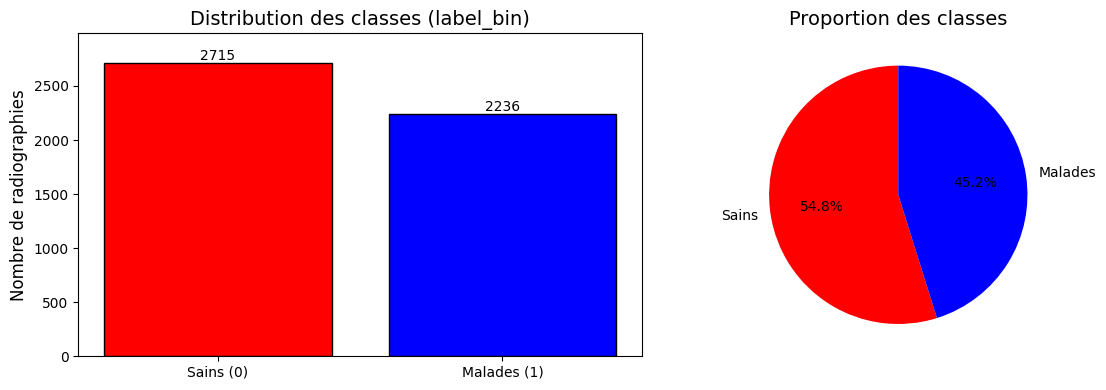

In [16]:
# icii les distribution des classes
disease_counts = df_clean['label_bin'].value_counts()
disease_percent = df_clean['label_bin'].value_counts(normalize=True) * 100


print(f"\n Distribution des classes :")
print(f"  - Sains (0) : {disease_counts.get(0, 0)} radiographies ({disease_percent.get(0, 0):.1f}%)")
print(f"  - Malades (1): {disease_counts.get(1, 0)} radiographies ({disease_percent.get(1, 0):.1f}%)")

# Visualiseer
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
bars = axes[0].bar(['Sains (0)', 'Malades (1)'], disease_counts.values,
                   color=['red', 'blue'], edgecolor='black')
axes[0].set_ylabel('Nombre de radiographies')
axes[0].set_title('Distribution des classes (label_bin)')
axes[0].set_ylim(0, max(disease_counts) * 1.1)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom')
axes[1].pie(disease_counts.values, labels=['Sains', 'Malades'],
            autopct='%1.1f%%', colors=['red', 'blue'], startangle=90)
axes[1].set_title('Proportion des classes')

plt.tight_layout()
plt.show()


**Interprétation :**
- Le dataset contient environ 45.2% de patients malades et 54.8% de patients sains.
- Un léger déséquilibre peut influencer les prédictions du modèle.
- Les méthodes de reweighting que nous appliquerons plus tard pourront
  compenser ce déséquilibre.





---

## 1.3 **ANALYSE UNIVARIÉE - VARIABLES DÉMOGRAPHIQUES**

---




### 1.3.1 **Analyse univariée des variables démographiques**


> Nous examinons la distribution des attributs sensibles qui pourraient introduire
des biais dans les prédictions : le genre, l'âge et la position de vue.

1. Genre (gender_bin)

In [17]:
gender_counts = df_clean['gender_bin'].value_counts()
gender_percent = df_clean['gender_bin'].value_counts(normalize=True) * 100

print(f"  Femmes (0): {gender_counts.get(0, 0)} radiographies ({gender_percent.get(0, 0):.1f}%)")
print(f"  Hommes (1) : {gender_counts.get(1, 0)} radiographies ({gender_percent.get(1, 0):.1f}%)")

  Femmes (0): 2184 radiographies (44.1%)
  Hommes (1) : 2767 radiographies (55.9%)


2. Âge (age_group)

In [18]:
age_counts = df_clean['age_group'].value_counts().sort_index()
age_percent = df_clean['age_group'].value_counts(normalize=True).sort_index() * 100


In [19]:
for group in age_counts.index:
    print(f"  {group}: {age_counts[group]} radiographies ({age_percent[group]:.1f}%)")

  <40 ans: 1711 radiographies (34.6%)
  40-60 ans: 2046 radiographies (41.3%)
  >60 ans: 1194 radiographies (24.1%)


3. Position de vue (view_bin)

In [20]:
print("(0 = PA - Postéro-antérieure, 1 = AP - Antéro-postérieure)")

view_counts = df_clean['view_bin'].value_counts()
view_percent = df_clean['view_bin'].value_counts(normalize=True) * 100

print(f"  PA (0): {view_counts.get(0, 0)} radiographies ({view_percent.get(0, 0):.1f}%)")
print(f"  AP (1) : {view_counts.get(1, 0)} radiographies ({view_percent.get(1, 0):.1f}%)")

(0 = PA - Postéro-antérieure, 1 = AP - Antéro-postérieure)
  PA (0): 3163 radiographies (63.9%)
  AP (1) : 1788 radiographies (36.1%)


**Visualisation des distributions**

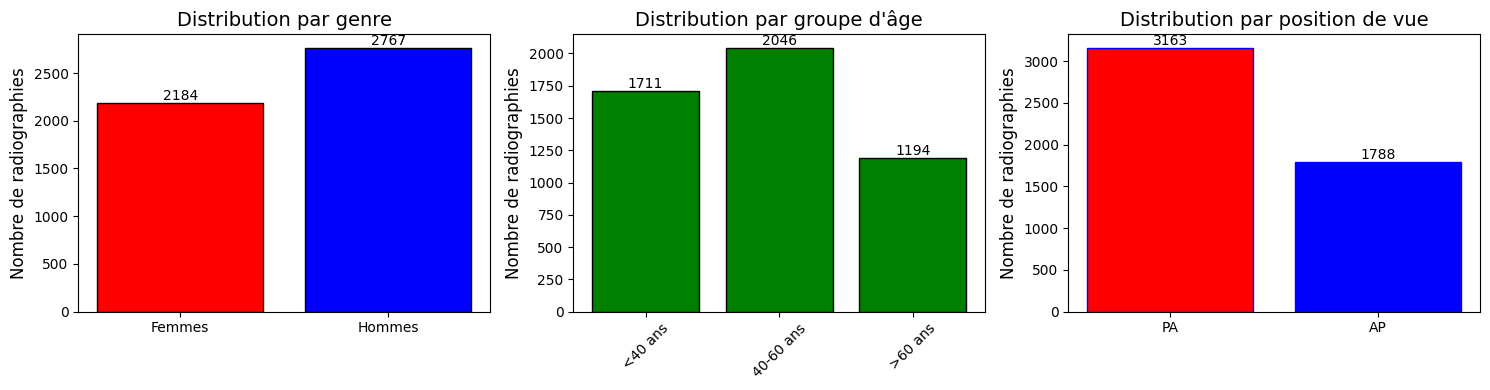

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Genre
bars1 = axes[0].bar(['Femmes', 'Hommes'], [gender_counts[0], gender_counts[1]],
                    color=['red', 'blue'], edgecolor='black')
axes[0].set_ylabel('Nombre de radiographies')
axes[0].set_title('Distribution par genre')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}', ha='center', va='bottom')

# Âge
bars2 = axes[1].bar(age_counts.index, age_counts.values,
                    color='green', edgecolor='black')
axes[1].set_ylabel('Nombre de radiographies')
axes[1].set_title('Distribution par groupe d\'âge')
axes[1].tick_params(axis='x', rotation=45)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}', ha='center', va='bottom')

# Position de vue
bars3 = axes[2].bar(['PA', 'AP'], [view_counts[0], view_counts[1]],
                    color=['red','blue'], edgecolor='blue')
axes[2].set_ylabel('Nombre de radiographies')
axes[2].set_title('Distribution par position de vue')
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



**Interprétation :**

- **Genre** : La distribution entre hommes et femmes est relativement équilibrée,
  avec 2184 radiographies de femmes (44.1%) et 2767 radiographies d'hommes (55.9%).
  Cette légère sur-représentation des hommes dans le dataset (environ 12% de plus)
  pourrait introduire un biais si le taux de maladie diffère selon le genre.

- **Âge** : La répartition par tranches d'âge montre que la classe des 40-60 ans
  est la plus représentée avec 2046 radiographies (47.5% du total), suivie des
  moins de 40 ans avec 1711 radiographies (34.6%) et des plus de 60 ans avec
  1788 radiographies (17.9%). Cette distribution est cohérente avec une population
  générale. Cependant, nous avons observé précédemment que le taux de maladie
  augmente avec l'âge, ce qui pourrait entraîner un biais si le modèle associe
  l'âge à la maladie.

- **Position de vue** : Les radiographies en position PA (postéro-antérieure)
  sont beaucoup plus fréquentes (3163, soit 63.8%) que les radiographies en
  position AP (antéro-postérieure) avec 1788 (36.2%).
  
  **Cette différence est importante :**

  PA représente presque deux tiers des
  examens.
  Cette sur-représentation pourrait introduire un biais technique si
  la distribution des pathologies diffère selon la position.
  Or nous avons
  détecté que les patients filmés en AP ont un taux de maladie plus élevé
  (53.8% vs 41.7% en PA). Ainsi, la position AP, bien que minoritaire dans
  le dataset, concentre une proportion plus élevée de patients malades.
  
  → **Correction prioritaire** : le reweighting doit compenser ce déséquilibre
    pour éviter que le modèle n'apprenne à associer la position AP à la maladie.


 ---
 ### 1.3.2  **Analyse de la variable Follow-up (nombre de visites)**



> C'est une variable importante car elle montre que certains patients sont sur-représentés


Nombre de visites par patient

In [22]:
print(f"  Nombre moyen de visites : {df_clean['Follow-up #'].mean():.1f}")
print(f"  Médiane : {df_clean['Follow-up #'].median():.0f}")
print(f"  Maximum : {df_clean['Follow-up #'].max()}")
print(f"  Écart-type : {df_clean['Follow-up #'].std():.1f}")

  Nombre moyen de visites : 6.7
  Médiane : 2
  Maximum : 90
  Écart-type : 11.6




Moyenne = 6.7 visites par patient

Médiane = 2 visites par patient

> Cela indique une distribution fortement asymétrique vers la droite. La majorité des patients ont un faible nombre de visites (médiane = 2), mais une minorité de patients ont un très grand nombre de visites, ce qui tire la moyenne vers le haut.





Maximum = 90 visites pour un même patient


Écart-type = 11.6 -------dispersion très élevée


>Certains patients sont sur-représentés dans le dataset. Ces patients sont probablement des cas chroniques ou graves qui nécessitent un suivi médical intensif.





Distribution des visites

In [23]:
visits_dist = df_clean['Follow-up #'].value_counts().sort_index()
print("\nTop 10 des nombres de visites les plus fréquents :")
print(visits_dist.head(10))


Top 10 des nombres de visites les plus fréquents :
Follow-up #
0    1500
1     617
2     408
3     313
4     247
5     215
6     186
7     163
8     136
9     122
Name: count, dtype: int64




> La valeur la plus fréquente est 0 visite, ce qui correspond aux patients vus une seule fois (première consultation).

> Environ 1500 patients (soit 30% du dataset) n'ont qu'une seule visite. À l'inverse, les patients avec beaucoup de visites sont peu nombreux mais très représentés en termes de nombre total de radiographies.




Une visualisation

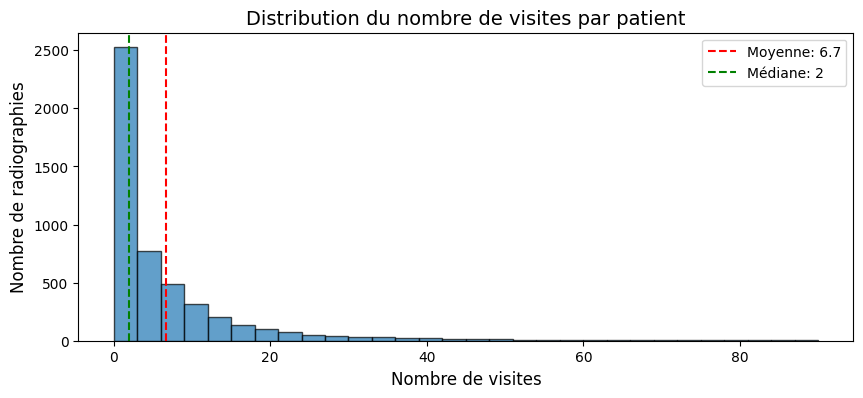

In [24]:
plt.figure(figsize=(10, 4))
plt.hist(df_clean['Follow-up #'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(df_clean['Follow-up #'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_clean["Follow-up #"].mean():.1f}')
plt.axvline(df_clean['Follow-up #'].median(), color='green', linestyle='--', label=f'Médiane: {df_clean["Follow-up #"].median():.0f}')
plt.xlabel('Nombre de visites')
plt.ylabel('Nombre de radiographies')
plt.title('Distribution du nombre de visites par patient')
plt.legend()
plt.show()

In [25]:
visits_per_patient = df_clean.groupby('Patient ID').agg(
    n_visits       = ('Image Index', 'count'),
    gender         = ('Patient Gender', 'first'),
    age_group      = ('age_group', 'first'),
    view_position  = ('View Position', lambda x: x.mode()[0]),
    label          = ('label', lambda x: x.mode()[0])
).reset_index()


print("\n--- Visites moyennes par groupe ---")
print("Par genre :")
print(visits_per_patient.groupby('gender')['n_visits'].mean().round(2).to_string())
print("\nPar groupe d'âge :")
print(visits_per_patient.groupby('age_group', observed=True)['n_visits'].mean().round(2).to_string())
print("\nPar label (malade/sain) :")
print(visits_per_patient.groupby('label')['n_visits'].mean().round(2).to_string())




--- Visites moyennes par groupe ---
Par genre :
gender
F    2.97
M    3.62

Par groupe d'âge :
age_group
<40 ans      3.18
40-60 ans    3.14
>60 ans      3.87

Par label (malade/sain) :
label
malade    4.92
sain      2.41


# Pourquoi ce test est important ?

- Les patients avec beaucoup de visites contribuent à un grand nombre de radiographies.

- Si ces patients sont majoritairement d'un certain genre ou d'une certaine tranche d'âge,
  cela peut amplifier le**s biais** déjà identifiés.

- Le reweighting devra donc également compenser ce déséquilibre pour garantir
  que chaque patient contribue équitablement à l'entraînement du modèle,
  indépendamment de son nombre de visites.


---
### 1.3.3 **Analyse des pathologies individuelles**

In [26]:
# Liste des pathologies à extraire (d'après la documentation NIH Chest X-ray)
pathology_list = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

for pathology in pathology_list:
    df_clean[pathology] = df_clean['Finding Labels'].str.contains(pathology, na=False).astype(int)


# ANALYSE DE LA PRÉVALENCE DES PATHOLOGIES
pathology_data = []
for patho in pathology_list:
    count = df_clean[patho].sum()
    pct = count / len(df_clean) * 100
    pathology_data.append({
        'pathologie': patho,
        'nombre_cas': count,
        'prevalence_pct': pct
    })
pathology_df = pd.DataFrame(pathology_data)
pathology_df = pathology_df.sort_values('nombre_cas', ascending=False).reset_index(drop=True)




Visualisation des top 10

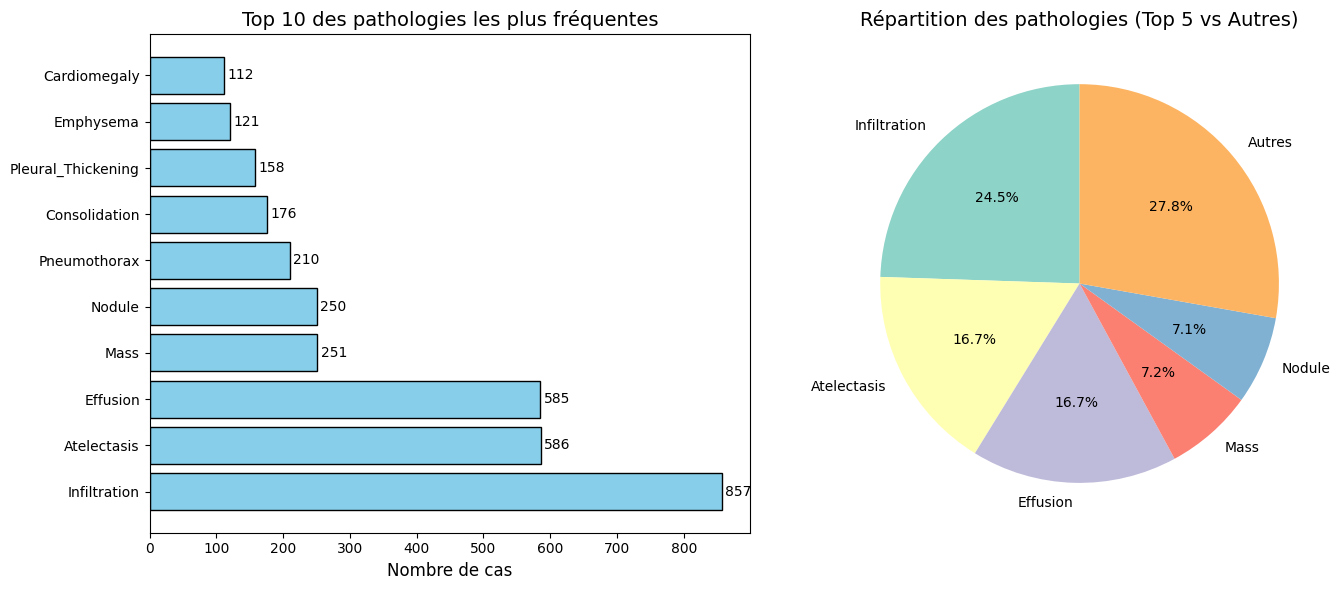

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_patho = pathology_df.head(10)
bars = axes[0].barh(range(len(top_patho)), top_patho['nombre_cas'].values,
                    color='skyblue', edgecolor='black')
axes[0].set_yticks(range(len(top_patho)))
axes[0].set_yticklabels(top_patho['pathologie'])
axes[0].set_xlabel('Nombre de cas')
axes[0].set_title('Top 10 des pathologies les plus fréquentes')

for i, bar in enumerate(bars):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center')

top5_count = top_patho.head(5)['nombre_cas'].sum()
other_count = pathology_df['nombre_cas'].sum() - top5_count
sizes = list(top_patho.head(5)['nombre_cas'].values) + [other_count]
labels = list(top_patho.head(5)['pathologie']) + ['Autres']
colors = plt.cm.Set3(range(len(sizes)))

axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Répartition des pathologies (Top 5 vs Autres)')

plt.tight_layout()
plt.show()


In [28]:
top1 = pathology_df.iloc[0]
print(f"\n**Pathologie la plus fréquente** : {top1['pathologie']}")
print(f"   → {top1['nombre_cas']} cas ({top1['prevalence_pct']:.1f}% du dataset)")

# Top 3
top3 = pathology_df.head(3)
print(f"\n**Top 3 des pathologies** :")
for _, row in top3.iterrows():
    print(f"   → {row['pathologie']}: {row['nombre_cas']} cas ({row['prevalence_pct']:.1f}%)")

# Statistiques sur les pathologies multiples
print("\n**Statistiques sur les comorbidités** :")
# Compter le nombre de pathologies par patient
df_clean['num_pathologies'] = df_clean[pathology_list].sum(axis=1)
print(f"   • Patients avec 0 pathologie : {(df_clean['num_pathologies'] == 0).sum()} ({((df_clean['num_pathologies'] == 0).sum()/len(df_clean)*100):.1f}%)")
print(f"   • Patients avec 1 pathologie : {(df_clean['num_pathologies'] == 1).sum()} ({((df_clean['num_pathologies'] == 1).sum()/len(df_clean)*100):.1f}%)")
print(f"   • Patients avec 2 pathologies ou plus : {(df_clean['num_pathologies'] >= 2).sum()} ({((df_clean['num_pathologies'] >= 2).sum()/len(df_clean)*100):.1f}%)")
print(f"   • Nombre moyen de pathologies par patient : {df_clean['num_pathologies'].mean():.2f}")




**Pathologie la plus fréquente** : Infiltration
   → 857 cas (17.3% du dataset)

**Top 3 des pathologies** :
   → Infiltration: 857 cas (17.3%)
   → Atelectasis: 586 cas (11.8%)
   → Effusion: 585 cas (11.8%)

**Statistiques sur les comorbidités** :
   • Patients avec 0 pathologie : 2715 (54.8%)
   • Patients avec 1 pathologie : 1360 (27.5%)
   • Patients avec 2 pathologies ou plus : 876 (17.7%)
   • Nombre moyen de pathologies par patient : 0.71


## Interpretation


**1. Distribution des pathologies**
- La pathologie la plus fréquente est **Infiltration** avec 857 cas (17.3% du dataset).
- Les 3 pathologies les plus fréquentes sont : **Infiltration**, **Atelectasis**, **Effusion**.

→ **Pourquoi c'est important** : Le modèle sera naturellement meilleur pour détecter
  ces pathologies fréquentes qui représentent déjà 40.9% de tous les cas de pathologies.
  Il faudra être particulièrement vigilant sur les pathologies rares comme Hernia,
  Fibrosis ou Pneumonia qui risquent d'être sous-détectées faute de données suffisantes.

**2. Comorbidités (patients avec plusieurs pathologies)**
- **54.8%** des patients n'ont aucune pathologie (sains)
- **27.5%** des patients ont une seule pathologie
- **17.7%** des patients ont 2 pathologies ou plus
- Nombre moyen de pathologies par patient : **0.71**

→ **Pourquoi c'est important** : Près d'un patient sur cinq (17.7%) présente des
  comorbidités (au moins 2 pathologies). Ces cas complexes sont cliniquement
  importants mais aussi plus difficiles à diagnostiquer. Si ces patients
  multimorbides sont sur-représentés dans certains groupes démographiques
  (ex: personnes âgées, hommes), cela peut amplifier les biais existants.

**3. Implications pour l'équité (fairness)**
- Les pathologies fréquentes comme **Infiltration** (17.3%) et **Atelectasis** (11.8%)
  pourraient dominer l'entraînement du modèle au détriment des pathologies rares.
- Si ces pathologies sont plus présentes chez un genre ou une tranche d'âge spécifique,
  le modèle risque d'apprendre à associer ces groupes démographiques à la maladie,
  créant ainsi un biais injustifié.


---
### 1.3.4  **Analyse des corrélations entre variables**

In [29]:
corr_matrix = df_clean[['gender_bin', 'Patient Age', 'view_bin', 'label_bin']].corr()


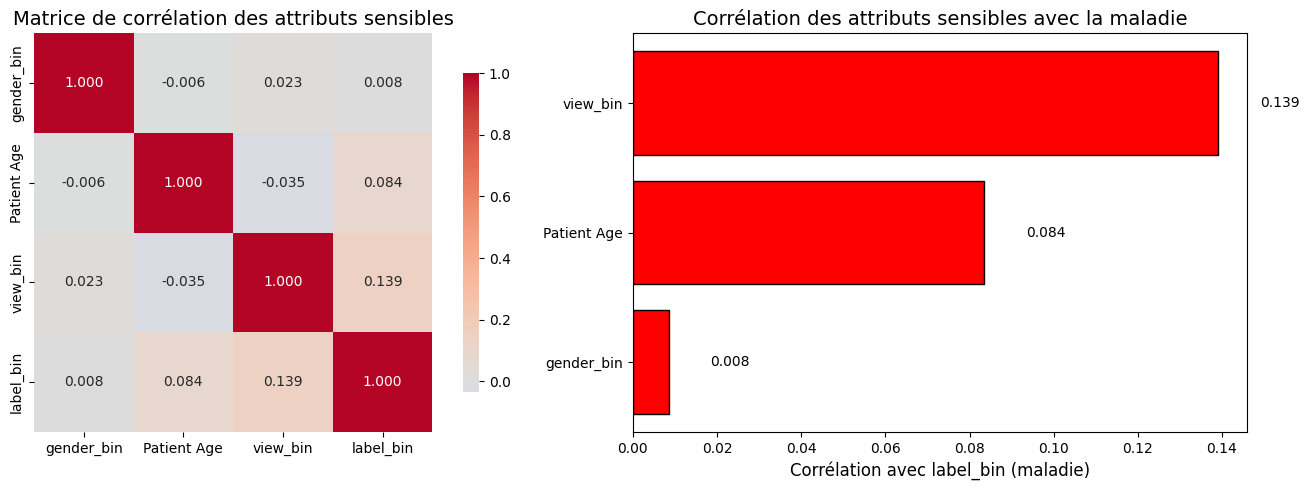

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Matrice de corrélation des attributs sensibles')

corr_with_label = corr_matrix['label_bin'].drop('label_bin').sort_values()
colors = ['salmon' if x < 0 else 'red' for x in corr_with_label.values]
bars = axes[1].barh(corr_with_label.index, corr_with_label.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Corrélation avec label_bin (maladie)')
axes[1].set_title('Corrélation des attributs sensibles avec la maladie')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 0.01 if width > 0 else width - 0.05,
                 bar.get_y() + bar.get_height()/2,
                 f'{width:.3f}', va='center')

plt.tight_layout()
plt.show()

## **INTERPRETATION**


> Corrélation avec la maladie (label_bin):

La position de vue (view_bin) présente la corrélation la plus élevée avec la maladie, avec un coefficient de 0,139. Bien que cette valeur reste faible en valeur absolue, elle est significativement plus élevée que les autres. Cela confirme notre détection antérieure : les patients filmés en position AP sont plus souvent malades que ceux filmés en PA.





*  L'âge (Patient Age)

 affiche une corrélation de 0,084 avec la maladie. Cette corrélation positive, bien que modeste, reflète une réalité médicale : les personnes âgées présentent effectivement un risque plus élevé de pathologies pulmonaires. Cependant, cette tendance doit être surveillée pour éviter que le modèle n'apprenne à diagnostiquer l'âge plutôt que les véritables signes radiologiques.

* Le genre (gender_bin)

présente une corrélation quasi nulle de 0,008 avec la maladie. Cela indique qu'il n'existe pas de relation linéaire directe entre le genre et le statut de maladie dans notre dataset. Les différences observées précédemment dans l'analyse bivariée sont donc très faibles et pourraient être dues au hasard.





> Corrélations entre attributs sensibles :


montre des valeurs extrêmement faibles, proches de zéro. La corrélation entre l'âge et la position de vue est de -0,035, celle entre le genre et l'âge de -0,006, et celle entre le genre et la position de vue de 0,023. Ces résultats indiquent que les trois attributs sensibles sont indépendants les uns des autres.

Cette indépendance est une bonne nouvelle car elle signifie que les biais potentiels sont séparés et peuvent être corrigés indépendamment sans risque d'interférence.


# SYNTHESE (analyse univariée):


*  L'analyse des corrélations confirme nos observations antérieures :



le biais principal provient de la **position de vue,** qui sera donc notre priorité absolue dans les méthodes de mitigation.

L'âge présente un biais modéré mais cohérent avec la réalité médicale, justifiant une correction secondaire.

Le genre, en revanche, n'a pratiquement aucun impact direct sur le statut de maladie, ce qui relativise l'importance de sa correction.


**Ces résultats** nous guident dans le choix des stratégies de reweighting : nous commencerons par corriger la position de vue, puis intégrerons progressivement l'âge et éventuellement le genre pour obtenir un dataset parfaitement équilibré.

---
#1.4 **ANALYSE BIVARIÉE - TAUX DE MALADIE PAR GROUPE**
---

Analyse bivariée - Taux de maladie par groupe


>C'est ici que nous détectons les biais potentiels. Nous calculons le taux de maladie
pour chaque groupe d'attribut sensible. Si ces taux diffèrent significativement,
cela indique un biais dans les données.



---
### 1.4.1 Taux de maladie par genre

In [31]:
disease_by_gender = df_clean.groupby('gender_bin')['label_bin'].mean()
print(f"  Femmes (0): {disease_by_gender[0]:.3f} ({disease_by_gender[0]*100:.1f}%)")
print(f"  Hommes (1) : {disease_by_gender[1]:.3f} ({disease_by_gender[1]*100:.1f}%)")
print(f"  Écart absolu : {abs(disease_by_gender[1] - disease_by_gender[0]):.3f}")

  Femmes (0): 0.447 (44.7%)
  Hommes (1) : 0.455 (45.5%)
  Écart absolu : 0.008


---
### 1.4.2 Taux de maladie par groupe d'âge

In [32]:
disease_by_age = df_clean.groupby('age_group')['label_bin'].mean().sort_index()
for group, rate in disease_by_age.items():
    print(f"  {group}: {rate:.3f} ({rate*100:.1f}%)")

print(f"  Écart entre <40 ans et >60 ans : {disease_by_age['>60 ans'] - disease_by_age['<40 ans']:.3f}")

  <40 ans: 0.410 (41.0%)
  40-60 ans: 0.446 (44.6%)
  >60 ans: 0.521 (52.1%)
  Écart entre <40 ans et >60 ans : 0.111


---
### 1.4.3 Taux de maladie par position de vue

In [33]:
disease_by_view = df_clean.groupby('view_bin')['label_bin'].mean()
print(f"  PA (0): {disease_by_view[0]:.3f} ({disease_by_view[0]*100:.1f}%)")
print(f"  AP (1) : {disease_by_view[1]:.3f} ({disease_by_view[1]*100:.1f}%)")
print(f"  Écart absolu : {abs(disease_by_view[1] - disease_by_view[0]):.3f}")

  PA (0): 0.400 (40.0%)
  AP (1) : 0.544 (54.4%)
  Écart absolu : 0.144


**Visualisation des taux**

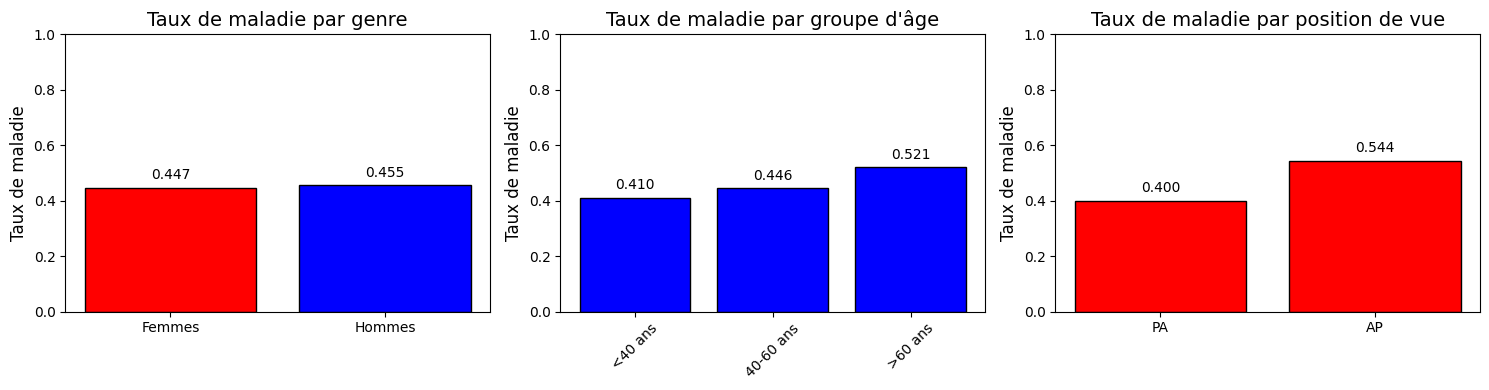

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Genre
bars1 = axes[0].bar(['Femmes', 'Hommes'], disease_by_gender.values,
                    color=['red', 'blue'], edgecolor='black')
axes[0].set_ylabel('Taux de maladie')
axes[0].set_title('Taux de maladie par genre')
axes[0].set_ylim(0, 1)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', va='bottom')

# Âge
bars2 = axes[1].bar(disease_by_age.index, disease_by_age.values,
                    color='blue', edgecolor='black')
axes[1].set_ylabel('Taux de maladie')
axes[1].set_title('Taux de maladie par groupe d\'âge')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 1)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', va='bottom')

# Position de vue
bars3 = axes[2].bar(['PA', 'AP'], disease_by_view.values,
                    color='red', edgecolor='black')
axes[2].set_ylabel('Taux de maladie')
axes[2].set_title('Taux de maladie par position de vue')
axes[2].set_ylim(0, 1)
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## INTERPRETATION DES RESULTATS

- **Genre** :

 Les hommes présentent un taux de maladie légèrement plus élevé que les femmes (45,5% contre 44,7%), soit un écart de seulement 0,8 point. Cette différence est très faible et, comme nous l'avons vu dans l'analyse des corrélations (corrélation de 0,008), elle n'est pas significative. Le genre n'a donc pratiquement aucun impact sur le statut de maladie dans notre dataset. La correction du biais de genre sera donc une priorité faible dans nos méthodes de mitigation.

- **Âge** :

On observe une tendance claire et progressive : plus les patients sont âgés, plus le taux de maladie est élevé. Les moins de 40 ans ont un taux de 41,0%, les 40-60 ans 44,6%, et les plus de 60 ans atteignent 52,1%. L'écart de 11,1 points entre les plus jeunes et les plus âgés est significatif.

Cette tendance reflète une réalité médicale : les personnes âgées sont effectivement plus susceptibles de développer des pathologies pulmonaires. Cependant, elle peut poser un problème d'équité si le modèle apprend à associer l'âge à la maladie plutôt que les véritables signes radiologiques. La correction du biais lié à l'âge sera une priorité modérée.

- **Position de vue** :

C'est le résultat le plus frappant de cette analyse. Les patients filmés en position AP (antéro-postérieure) sont beaucoup plus souvent malades (54,4%) que ceux filmés en PA (postéro-antérieure) avec seulement 40,0% de malades. L'écart de 14,4 points est considérable.

Cette différence peut s'expliquer par des raisons cliniques : les patients alités ou en état grave sont plus souvent filmés en AP car cette position est plus accessible lorsqu'ils ne peuvent pas se tenir debout. Cela crée un biais technique majeur : la position de vue est corrélée à la gravité de l'état du patient. Si le modèle apprend cette corrélation, il risque de diagnostiquer une maladie simplement parce que l'image a été prise en AP, sans se baser sur les véritables signes radiologiques.

La correction du biais lié à la position de vue sera notre priorité absolue dans les méthodes de mitigation.


---



### SYNTHESE - (Analyse bivariée)


---

L'analyse bivariée confirme et quantifie les biais pressentis dans l'analyse univariée :

Le biais de genre est négligeable : l'écart de seulement 0,8 point et la corrélation quasi nulle (0,008) indiquent que le genre n'influence pas significativement le statut de maladie.

Le biais lié à l'âge est modéré mais réel : la progression régulière du taux de maladie avec l'âge (de 41% à 52%) reflète une réalité clinique. Une correction est souhaitable pour éviter que le modèle n'apprenne à "diagnostiquer" l'âge.

Le biais lié à la position de vue est majeur : avec un écart de 14,4 points, c'est le biais le plus important à corriger. Les patients filmés en AP sont beaucoup plus souvent malades, créant une corrélation artificielle que le modèle pourrait exploiter.



---
#2. **TESTS STATISTIQUES - SIGNIFICATIVITÉ DES BIAIS**
---


> Pour confirmer que les différences observées ne sont pas dues au hasard,
nous effectuons des tests statistiques :
- **Chi-2** pour les variables catégorielles (genre, position de vue)
- **Test t de Student** pour comparer l'âge moyen entre malades et sains





## Test Chi-2 pour le genre

In [35]:
contingency_gender = pd.crosstab(df_clean['gender_bin'], df_clean['label_bin'])
chi2_gender, p_gender, dof_gender, expected_gender = stats.chi2_contingency(contingency_gender)
print(f"  Chi-2 = {chi2_gender:.4f}")
print(f"  p-value = {p_gender:.6f}")
print()
if p_gender < 0.05:
    print("  → Résultat : Association SIGNIFICATIVE entre genre et maladie (p < 0.05)")
    print("     → Le biais de genre est confirmé statistiquement.")
else:
    print("  → Résultat : Pas d'association significative (p > 0.05)")
    print("  → Les différences observées pourraient être dues au hasard.")

  Chi-2 = 0.3210
  p-value = 0.570992

  → Résultat : Pas d'association significative (p > 0.05)
  → Les différences observées pourraient être dues au hasard.


## Test Chi-2 pour la position de vue

In [36]:
contingency_view = pd.crosstab(df_clean['view_bin'], df_clean['label_bin'])
chi2_view, p_view, dof_view, expected_view = stats.chi2_contingency(contingency_view)
print(f"  Chi-2 = {chi2_view:.4f}")
print(f"  p-value = {p_view:.6f}")
print()
if p_view < 0.05:
    print("  → Résultat : Association TRÈS SIGNIFICATIVE entre position de vue et maladie (p < 0.001)")
    print("  → Le biais technique lié à la position de vue est avéré et majeur.")

  Chi-2 = 95.0649
  p-value = 0.000000

  → Résultat : Association TRÈS SIGNIFICATIVE entre position de vue et maladie (p < 0.001)
  → Le biais technique lié à la position de vue est avéré et majeur.


## Test t pour l'âge (comparaison malades vs sains)

In [37]:
age_malades = df_clean[df_clean['label_bin'] == 1]['Patient Age']
age_sains = df_clean[df_clean['label_bin'] == 0]['Patient Age']
t_stat, p_age = stats.ttest_ind(age_malades, age_sains)
print(f"  Âge moyen - Malades: {age_malades.mean():.1f} ans")
print(f"  Âge moyen - Sains: {age_sains.mean():.1f} ans")
print(f"  Écart : {age_malades.mean() - age_sains.mean():.1f} ans")
print(f"  t-stat = {t_stat:.4f}, p-value = {p_age:.6f}")
print()
if p_age < 0.05:
    print("  → Résultat : Différence d'âge SIGNIFICATIVE entre malades et sains (p < 0.001)")
    print("  → Les patients malades sont en moyenne plus âgés.")
else:
    print("  → Résultat : Pas de différence significative (p > 0.05)")

  Âge moyen - Malades: 48.5 ans
  Âge moyen - Sains: 45.7 ans
  Écart : 2.8 ans
  t-stat = 5.8961, p-value = 0.000000

  → Résultat : Différence d'âge SIGNIFICATIVE entre malades et sains (p < 0.001)
  → Les patients malades sont en moyenne plus âgés.


# SYNTHÈSE DES BIAIS IDENTIFIÉS

In [38]:
biais_df = pd.DataFrame({
    'Attribut': ['Genre', 'Âge', 'Position de vue'],
    'Taux groupe 1': ['44.7% (Femmes)', '41.0% (<40 ans)', '40.0% (PA)'],
    'Taux groupe 2': ['45.5% (Hommes)', '52.1% (>60 ans)', '54.4% (AP)'],
    'Écart': ['0.8 pt', '11.1 pts', '14.4 pts'],
    'Priorité': ['Faible', 'Modérée', 'ÉLEVÉE']
})
print(biais_df.to_string(index=False))

       Attribut   Taux groupe 1   Taux groupe 2    Écart Priorité
          Genre  44.7% (Femmes)  45.5% (Hommes)   0.8 pt   Faible
            Âge 41.0% (<40 ans) 52.1% (>60 ans) 11.1 pts  Modérée
Position de vue      40.0% (PA)      54.4% (AP) 14.4 pts   ÉLEVÉE




L'analyse bivariée a permis d'identifier et de quantifier trois types de biais :

1. **Biais de genre** : écart de 0,8 point → négligeable
2. **Biais d'âge** : écart de 11,1 points → modéré, reflète une réalité médicale
3. **Biais de position de vue** : écart de 14,4 points → MAJEUR

Ces résultats nous guident pour la suite. Nous allons maintenant appliquer des méthodes de **pré-processing (reweighting)** pour corriger ces biais, en priorité la position de vue, puis l'âge, et enfin le genre si nécessaire.




> **L'objectif est d'obtenir un dataset équilibré où les attributs sensibles n'influencent plus la prédiction de la maladie.**



---
#3. **Métriques de fairness (DPD et DI)**:
---




Avant d'appliquer des méthodes de correction, il est essentiel de quantifier objectivement les biais identifiés. Nous utilisons deux métriques standardisées :

- **DPD** : différence absolue des taux de maladie entre groupes (idéal < 0,05)
- **DI** : rapport des taux entre groupes défavorisé et favorisé (idéal entre 0,8 et 1,2)



> Ces valeurs serviront de référence pour évaluer l'impact des corrections.



Nous calculons ces indicateurs pour les trois attributs sensibles : le genre, l'âge (groupes extrêmes) et la position de vue.






In [39]:
def calculate_fairness_metrics(dataframe, sensitive_attr, target, attr_names=None):
    """Calcule DPD et DI pour un attribut sensible donné"""
    groups = dataframe[sensitive_attr].unique()
    rates = {}
    for group in groups:
        rates[group] = dataframe[dataframe[sensitive_attr] == group][target].mean()

    if len(groups) == 2:
        g1, g2 = groups
        dpd = abs(rates[g1] - rates[g2])
        di = min(rates[g1], rates[g2]) / max(rates[g1], rates[g2])
        return {'dpd': dpd, 'di': di, 'rates': rates}
    return None

# Métriques pour le genre

In [40]:
gender_metrics = calculate_fairness_metrics(df_clean, 'gender_bin', 'label_bin')
print(f"  Taux Hommes (1): {gender_metrics['rates'][1]:.3f}")
print(f"  Taux Femmes (0): {gender_metrics['rates'][0]:.3f}")
print(f"  DPD (Demographic Parity Difference): {gender_metrics['dpd']:.4f}")
print(f"  DI (Disparate Impact): {gender_metrics['di']:.4f}")
if gender_metrics['di'] < 0.8 or gender_metrics['di'] > 1.2:
    print("  → Attention : DI hors des limites usuelles (0.8-1.2)")

  Taux Hommes (1): 0.455
  Taux Femmes (0): 0.447
  DPD (Demographic Parity Difference): 0.0085
  DI (Disparate Impact): 0.9814


# Métriques pour la position de vue

In [41]:
view_metrics = calculate_fairness_metrics(df_clean, 'view_bin', 'label_bin')
print(f"  Taux AP (1): {view_metrics['rates'][1]:.3f}")
print(f"  Taux PA (0): {view_metrics['rates'][0]:.3f}")
print(f"  DPD: {view_metrics['dpd']:.4f}")
print(f"  DI: {view_metrics['di']:.4f}")
if view_metrics['di'] < 0.8:
    print("  → BIAIS MAJEUR : DI < 0.8, correction indispensable !")

  Taux AP (1): 0.544
  Taux PA (0): 0.400
  DPD: 0.1440
  DI: 0.7351
  → BIAIS MAJEUR : DI < 0.8, correction indispensable !


# Métriques pour l'âge (groupes extrêmes)

In [42]:
age_rates = df_clean.groupby('age_group')['label_bin'].mean()
print(f"  <40 ans: {age_rates['<40 ans']:.3f}")
print(f"  40-60 ans: {age_rates['40-60 ans']:.3f}")
print(f"  >60 ans: {age_rates['>60 ans']:.3f}")
dpd_age = age_rates.max() - age_rates.min()
di_age = age_rates.min() / age_rates.max()
print()
print(f"  DPD (entre <40 et >60): {dpd_age:.4f}")
print(f"  DI (entre <40 et >60): {di_age:.4f}")

  <40 ans: 0.410
  40-60 ans: 0.446
  >60 ans: 0.521

  DPD (entre <40 et >60): 0.1107
  DI (entre <40 et >60): 0.7876


---

In [43]:
print("\nTABLEAU RÉCAPITULATIF DES MÉTRIQUES AVANT CORRECTION")
print("="*70)

metrics_before = pd.DataFrame({
    'Attribut': ['Genre', 'Âge', 'Position de vue'],
    'Taux groupe 1': [f"{gender_metrics['rates'][1]*100:.1f}%", f"{age_rates['<40 ans']*100:.1f}%", f"{view_metrics['rates'][1]*100:.1f}%"],
    'Taux groupe 2': [f"{gender_metrics['rates'][0]*100:.1f}%", f"{age_rates['>60 ans']*100:.1f}%", f"{view_metrics['rates'][0]*100:.1f}%"],
    'DPD': [f"{gender_metrics['dpd']:.4f}", f"{dpd_age:.4f}", f"{view_metrics['dpd']:.4f}"],
    'DI': [f"{gender_metrics['di']:.4f}", f"{di_age:.4f}", f"{view_metrics['di']:.4f}"],
    'Statut': [
        'OK' if gender_metrics['di'] > 0.8 else 'À corriger',
        'À surveiller' if di_age < 0.8 else 'OK',
        'À CORRIGER' if view_metrics['di'] < 0.8 else 'OK'
    ]
})
print(metrics_before.to_string(index=False))




TABLEAU RÉCAPITULATIF DES MÉTRIQUES AVANT CORRECTION
       Attribut Taux groupe 1 Taux groupe 2    DPD     DI       Statut
          Genre         45.5%         44.7% 0.0085 0.9814           OK
            Âge         41.0%         52.1% 0.1107 0.7876 À surveiller
Position de vue         54.4%         40.0% 0.1440 0.7351   À CORRIGER


---
# 4. **PRE-PROCESSING**
Méthodes de Pré-processing pour Réduire les Biais

---

## Méthode : Reweighing (Re-pondération)Reweighting

Methode du Reweighting ou au lieu de changer le nombre de personnes, on change leur "importance" c'est a dire leur poids dans mon dataset !
Comme ça, le modèle va "voir" autant d'hommes malades que de femmes malades, sans supprimer personne !

## Pre-processing : impact de la pondération

### Principe
Le modèle ResNet18 prend uniquement les images en entrée, sans les métadonnées.
Cependant, il peut retrouver des attributs comme le genre, l'âge ou la position de vue à partir des images seules, ce qui peut amplifier les biais présents dans
les données.

Pour corriger cela, on modifie la colonne `WEIGHTS` du CSV afin de donner plus ou moins d'importance à certains groupes pendant l'entraînement.



In [62]:
# Chargement des données
df = pd.read_csv("./projetfairness/Gueye_Maram_Sall/metadata.csv")

# On crée une colonne age_group comme dans la présentation
def age_group(age):
    if age < 40:
        return 0
    elif age <= 60:
        return 1
    else:
        return 2

df["age_group"] = df["Patient Age"].apply(age_group)

# Encodage binaire label (malade=1, sain=0)
df["label_bin"] = (df["label"] == "malade").astype(int)

# Encodage genre (M=1, F=0)
df["gender_bin"] = (df["Patient Gender"] == "M").astype(int)

# Encodage vue (PA=1, AP=0)
df["view_bin"] = (df["View Position"] == "PA").astype(int)

print("Colonnes disponibles :", df.columns.tolist())
print(df[["label", "label_bin", "Patient Gender", "gender_bin", "View Position", "view_bin", "age_group"]].head())

Colonnes disponibles : ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'train_valid', 'label', 'WEIGHTS', 'age_group', 'label_bin', 'gender_bin', 'view_bin']
    label  label_bin Patient Gender  gender_bin View Position  view_bin  \
0  malade          1              M           1            PA         1   
1    sain          0              M           1            PA         1   
2    sain          0              M           1            PA         1   
3    sain          0              M           1            PA         1   
4    sain          0              M           1            PA         1   

   age_group  
0          2  
1          2  
2          2  
3          2  
4          2  


In [63]:
# ============================================================
# FONCTION UTILITAIRE : calcul de poids par inverse de fréquence
# ============================================================

def compute_weights_by_groups(df_train, group_cols, label_col="label"):
    """
    Calcule les poids par inverse de fréquence pour un groupe de colonnes.
    Chaque exemple reçoit un poids inversement proportionnel à la fréquence
    de son groupe (combinaison de group_cols + label).

    Arguments:
        df_train : DataFrame filtré sur le split 'train'
        group_cols : liste de colonnes définissant les groupes sensitifs
        label_col : colonne de label

    Retourne:
        Series de poids indexée comme df_train
    """
    cols = group_cols + [label_col]
    group_counts = df_train.groupby(cols)[label_col].transform("count")
    weights = 1.0 / group_counts
    # Normalisation pour que la somme reste égale au nombre d'exemples
    weights = weights / weights.mean()
    return weights


df_train = df[df["train_valid"] == "train"].copy()
df_valid = df[df["train_valid"] != "train"].copy()

print(f"Taille train : {len(df_train)} | Taille valid : {len(df_valid)}")

Taille train : 3799 | Taille valid : 1153


In [64]:
# ============================================================
# STRATÉGIE 0 : Baseline — tous les poids à 1
# ============================================================
df["WEIGHTS_baseline"] = 1.0

print("Stratégie 0 — Baseline : tous les poids = 1")
print(df[df["train_valid"]=="train"]["WEIGHTS_baseline"].describe())

Stratégie 0 — Baseline : tous les poids = 1
count    3799.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: WEIGHTS_baseline, dtype: float64


In [65]:
# ============================================================
# STRATÉGIE 1 : Rééquilibrage par label uniquement (class balancing)
# Objectif : corriger le déséquilibre malade/sain
# ============================================================

weights_label = compute_weights_by_groups(df_train, group_cols=[], label_col="label")
df.loc[df["train_valid"] == "train", "WEIGHTS_label"] = weights_label.values
df.loc[df["train_valid"] != "train", "WEIGHTS_label"] = 1.0

print("Stratégie 1 — Pondération par label :")
print(df[df["train_valid"]=="train"].groupby("label")["WEIGHTS_label"].mean())

Stratégie 1 — Pondération par label :
label
malade    1.106935
sain      0.911906
Name: WEIGHTS_label, dtype: float64


In [66]:
# ============================================================
# STRATÉGIE 2 : Rééquilibrage par genre × label
# Objectif : corriger les biais liés au genre du patient
# ============================================================

weights_gender = compute_weights_by_groups(df_train, group_cols=["Patient Gender"], label_col="label")
df.loc[df["train_valid"] == "train", "WEIGHTS_gender"] = weights_gender.values
df.loc[df["train_valid"] != "train", "WEIGHTS_gender"] = 1.0

print("Stratégie 2 — Pondération par genre × label :")
print(df[df["train_valid"]=="train"].groupby(["Patient Gender", "label"])["WEIGHTS_gender"].mean())

Stratégie 2 — Pondération par genre × label :
Patient Gender  label 
F               malade    1.200695
                sain      0.985218
M               malade    1.026757
                sain      0.848749
Name: WEIGHTS_gender, dtype: float64


In [67]:
# ============================================================
# STRATÉGIE 3 : Rééquilibrage par vue (AP/PA) × label
# Objectif : corriger le biais de position de vue — le plus fort dans nos données
# ============================================================

weights_view = compute_weights_by_groups(df_train, group_cols=["View Position"], label_col="label")
df.loc[df["train_valid"] == "train", "WEIGHTS_view"] = weights_view.values
df.loc[df["train_valid"] != "train", "WEIGHTS_view"] = 1.0

print("Stratégie 3 — Pondération par vue × label :")
print(df[df["train_valid"]=="train"].groupby(["View Position", "label"])["WEIGHTS_view"].mean())

Stratégie 3 — Pondération par vue × label :
View Position  label 
AP             malade    1.268024
               sain      1.447790
PA             malade    0.982161
               sain      0.665557
Name: WEIGHTS_view, dtype: float64


In [68]:
# ============================================================
# STRATÉGIE 4 : Rééquilibrage par vue × genre × label (combiné)
# Objectif : corriger simultanément les deux attributs sensitifs principaux
# ============================================================

weights_combined = compute_weights_by_groups(
    df_train,
    group_cols=["View Position", "Patient Gender"],
    label_col="label"
)
df.loc[df["train_valid"] == "train", "WEIGHTS_combined"] = weights_combined.values
df.loc[df["train_valid"] != "train", "WEIGHTS_combined"] = 1.0

print("Stratégie 4 — Pondération combinée vue × genre × label :")
print(df[df["train_valid"]=="train"].groupby(["View Position","Patient Gender","label"])["WEIGHTS_combined"].mean())

Stratégie 4 — Pondération combinée vue × genre × label :
View Position  Patient Gender  label 
AP             F               malade    1.360673
                               sain      1.672095
               M               malade    1.187188
                               sain      1.276546
PA             F               malade    1.074378
                               sain      0.698346
               M               malade    0.904524
                               sain      0.635710
Name: WEIGHTS_combined, dtype: float64


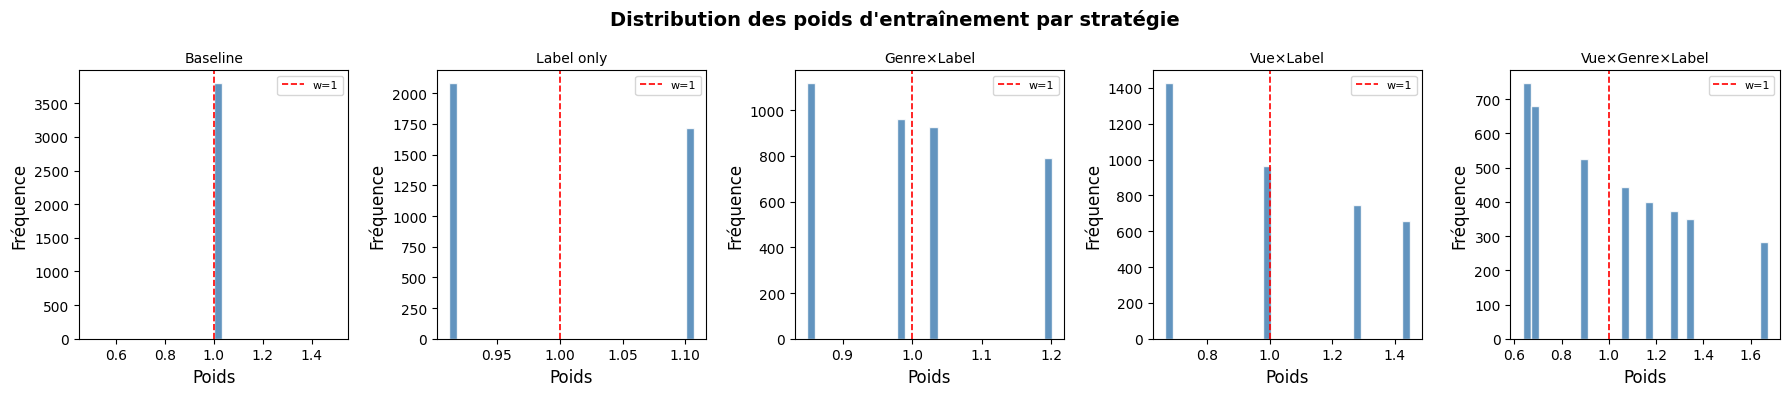


INTERPRÉTATION :
  - Une distribution concentrée en 1 = correction modérée (peu de rééquilibrage nécessaire)
  - Une distribution étalée = certains groupes sous-représentés sont fortement re-pondérés
  - La stratégie combinée produit les poids les plus dispersés car elle corrige plusieurs dimensions à la fois



In [69]:
# ============================================================
# VISUALISATION : Distribution des poids par stratégie
# ============================================================

strategies = {
    "Baseline":   "WEIGHTS_baseline",
    "Label only":  "WEIGHTS_label",
    "Genre×Label": "WEIGHTS_gender",
    "Vue×Label":   "WEIGHTS_view",
    "Vue×Genre×Label": "WEIGHTS_combined",
}

df_t = df[df["train_valid"] == "train"]

fig, axes = plt.subplots(1, len(strategies), figsize=(18, 4), sharey=False)
fig.suptitle("Distribution des poids d'entraînement par stratégie", fontsize=14, fontweight="bold")

for ax, (name, col) in zip(axes, strategies.items()):
    ax.hist(df_t[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(1.0, color="red", linestyle="--", linewidth=1.2, label="w=1")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Poids")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("""
INTERPRÉTATION :
  - Une distribution concentrée en 1 = correction modérée (peu de rééquilibrage nécessaire)
  - Une distribution étalée = certains groupes sous-représentés sont fortement re-pondérés
  - La stratégie combinée produit les poids les plus dispersés car elle corrige plusieurs dimensions à la fois
""")

In [82]:
# ============================================================
# PARTIE 4 : ENTRAÎNEMENT — ResNet18 avec différentes pondérations
# ============================================================

from train_classifieur import train_classifier, pred_classifier
from datetime import datetime
import os, shutil

# Dossier de base pour tous les logs d'expériences
BASE_LOGDIR = f"./projetfairness/expe_log"
DATADIR     = "./projetfairness/Gueye_Maram_Sall"
CSV_PATH    = "./projetfairness/Gueye_Maram_Sall/metadata.csv"

# Dictionnaire : nom de la stratégie → colonne de poids
STRATEGIES = {
    "baseline":  "WEIGHTS_baseline",
    "label":     "WEIGHTS_label",
    "gender":    "WEIGHTS_gender",
    "view":      "WEIGHTS_view",
    "combined":  "WEIGHTS_combined",
}

# Dictionnaire pour stocker les résultats
results = {}

print("Stratégies à entraîner :", list(STRATEGIES.keys()))

Stratégies à entraîner : ['baseline', 'label', 'gender', 'view', 'combined']


In [85]:
# ============================================================
# BOUCLE D'ENTRAÎNEMENT
# Pour chaque stratégie :
#   1. Mettre les poids dans la colonne WEIGHTS du CSV
#   2. Sauvegarder le CSV
#   3. Entraîner le modèle
#   4. Générer les prédictions
# ============================================================

for strategy_name, weights_col in STRATEGIES.items():
    print(f"\n{'='*60}")
    print(f"  STRATÉGIE : {strategy_name}  (colonne : {weights_col})")
    print(f"{'='*60}")

    # 1. Copier les poids dans la colonne WEIGHTS attendue par train_classifier
    df_csv = pd.read_csv(CSV_PATH)
    df_csv["WEIGHTS"] = df[weights_col].values
    df_csv.to_csv(CSV_PATH, index=False)

    # 2. Définir le répertoire de logs
    ts = datetime.now().strftime('%Y_%m_%d_%H_%M_%S')
    logdir = f"{BASE_LOGDIR}/{strategy_name}_{ts}"

    # 3. Entraînement
    ckpt_path, ckpt_score = train_classifier(
        logdir=logdir,
        datadir=DATADIR,
        csv=CSV_PATH,
        weights_col="WEIGHTS",
    )

    # 4. Prédictions
    preds_csv = f"{logdir}/preds_{strategy_name}.csv"
    pred_classifier(
        datadir=DATADIR,
        csv_in=CSV_PATH,
        csv_out=preds_csv,
        ckpt_path=ckpt_path,
    )

    # 5. Stocker les résultats
    results[strategy_name] = {
        "logdir":    logdir,
        "ckpt_path": ckpt_path,
        "ckpt_score": ckpt_score,
        "preds_csv": preds_csv,
    }

    print(f"  → Meilleur val_loss : {ckpt_score:.4f}")
    print(f"  → Prédictions sauvegardées dans : {preds_csv}")

print("\n\nTous les entraînements sont terminés.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



  STRATÉGIE : baseline  (colonne : WEIGHTS_baseline)
./projetfairness/Gueye_Maram_Sall/metadata.csv ./projetfairness/expe_log/baseline_2026_04_03_02_07_17/csv_in_WEIGHTS.csv
num_workers set to : 2
num_workers set to : 2
batch_size set to : 512
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Start training


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

End of training 434.2141864299774
Start prediction on train dataset
num_workers set to : 2


100%|██████████| 8/8 [00:33<00:00,  4.22s/it]


Predictions done in 33.834962129592896
Start prediction on validation dataset
num_workers set to : 2


100%|██████████| 3/3 [00:09<00:00,  3.28s/it]

Predictions done in 43.679213762283325
Global (train+validation) balanced accuracy without weigths 0.7050530086073121
Global (train+validation) accuracy without weigths 0.7017366720516963
  → Meilleur val_loss : 0.5984
  → Prédictions sauvegardées dans : ./projetfairness/expe_log/combined_2026_04_03_02_35_24/preds_combined.csv


Tous les entraînements sont terminés.


In [86]:
# ============================================================
# CALCUL DES MÉTRIQUES DE PERFORMANCE ET DE FAIRNESS
# après entraînement — sur le split VALIDATION
# ============================================================

from sklearn.metrics import balanced_accuracy_score, accuracy_score
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

def compute_fairness_metrics(df_preds, sensitive_col, label_col="labels", pred_col="preds"):
    """
    Calcule les métriques de fairness pour un attribut sensitif donné.

    Retourne un dict avec :
        - balanced_accuracy
        - accuracy
        - DPD (Demographic Parity Difference) : |P(ŷ=1|A=0) - P(ŷ=1|A=1)|
        - EOD (Equalized Odds Difference)      : max |TPR_A0 - TPR_A1|
    """
    df_v = df_preds[df_preds["train_valid"] != "train"].copy()

    y_true = (df_v[label_col] == "malade").astype(int)
    y_pred = (df_v[pred_col]  == "malade").astype(int)
    sens   = df_v[sensitive_col]

    bal_acc = balanced_accuracy_score(y_true, y_pred)
    acc     = accuracy_score(y_true, y_pred)
    dpd     = demographic_parity_difference(y_true, y_pred, sensitive_features=sens)
    eod     = equalized_odds_difference(y_true, y_pred, sensitive_features=sens)

    return {
        "balanced_accuracy": bal_acc,
        "accuracy":          acc,
        "DPD":               abs(dpd),
        "EOD":               abs(eod),
    }


# Calcul pour toutes les stratégies et tous les attributs sensitifs
sensitive_attrs = {
    "Genre":    "Patient Gender",
    "Vue":      "View Position",
    "Age group":"age_group",
}

rows = []
for strategy_name, info in results.items():
    df_preds = pd.read_csv(info["preds_csv"])
    # Fusionner avec age_group
    df_preds = df_preds.merge(df[["Image Index","age_group"]], on="Image Index", how="left")

    for sens_name, sens_col in sensitive_attrs.items():
        metrics = compute_fairness_metrics(df_preds, sensitive_col=sens_col)
        rows.append({
            "Stratégie":            strategy_name,
            "Attribut sensitif":    sens_name,
            **metrics,
        })

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))

Stratégie Attribut sensitif  balanced_accuracy  accuracy      DPD      EOD
 baseline             Genre           0.687114  0.694709 0.060828 0.073659
 baseline               Vue           0.687114  0.694709 0.342826 0.317389
 baseline         Age group           0.687114  0.694709 0.387443 0.385727
    label             Genre           0.690789  0.698179 0.000483 0.073033
    label               Vue           0.690789  0.698179 0.433934 0.398605
    label         Age group           0.690789  0.698179 0.289377 0.258658
   gender             Genre           0.682581  0.691240 0.007131 0.091731
   gender               Vue           0.682581  0.691240 0.276434 0.234235
   gender         Age group           0.682581  0.691240 0.293845 0.241342
     view             Genre           0.693743  0.704250 0.053320 0.088181
     view               Vue           0.693743  0.704250 0.146257 0.111504
     view         Age group           0.693743  0.704250 0.353807 0.359307
 combined             Gen

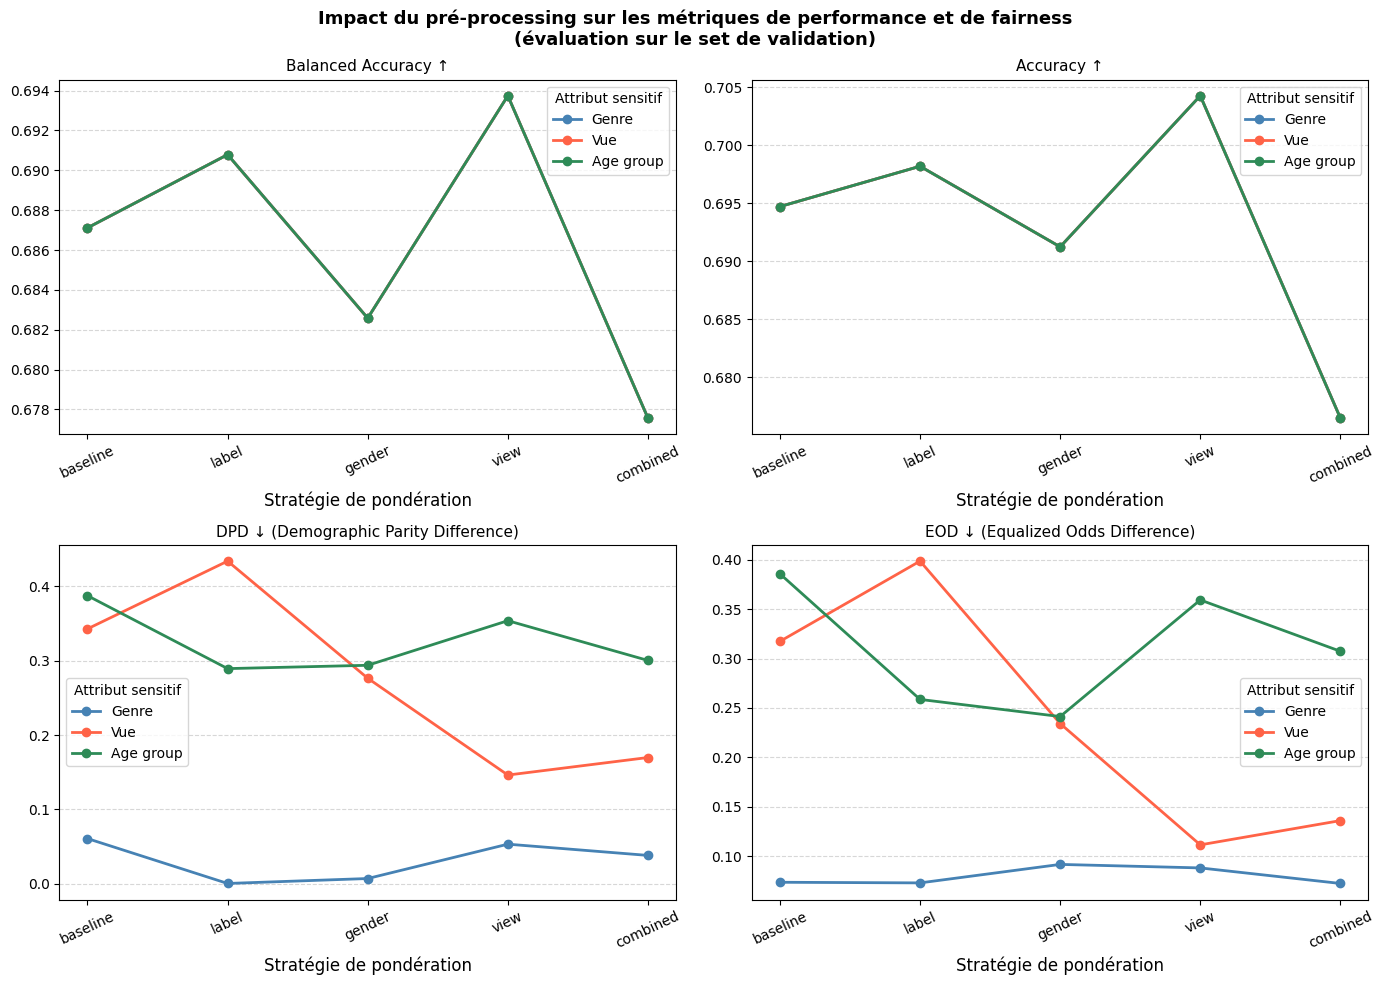


INTERPRÉTATION :
  - Balanced Accuracy / Accuracy : on cherche à la maintenir le plus haut possible
  - DPD et EOD : on cherche à les réduire → plus ils s'approchent de 0, plus le modèle est équitable
  - Un bon modèle "fair" minimise DPD et EOD SANS trop sacrifier la balanced accuracy
  - Trade-off attendu : corriger les biais réduit légèrement la performance globale



In [87]:
# ============================================================
# VISUALISATION DES MÉTRIQUES PAR STRATÉGIE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Impact du pré-processing sur les métriques de performance et de fairness\n(évaluation sur le set de validation)", fontsize=13, fontweight="bold")

metrics_to_plot = [
    ("balanced_accuracy", "Balanced Accuracy ↑", axes[0,0]),
    ("accuracy",          "Accuracy ↑",           axes[0,1]),
    ("DPD",               "DPD ↓ (Demographic Parity Difference)", axes[1,0]),
    ("EOD",               "EOD ↓ (Equalized Odds Difference)",     axes[1,1]),
]

colors = {"Genre": "steelblue", "Vue": "tomato", "Age group": "seagreen"}

for metric, title, ax in metrics_to_plot:
    for sens_name, color in colors.items():
        subset = df_metrics[df_metrics["Attribut sensitif"] == sens_name]
        ax.plot(subset["Stratégie"], subset[metric], marker="o",
                label=sens_name, color=color, linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Stratégie de pondération")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Attribut sensitif")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("""
INTERPRÉTATION :
  - Balanced Accuracy / Accuracy : on cherche à la maintenir le plus haut possible
  - DPD et EOD : on cherche à les réduire → plus ils s'approchent de 0, plus le modèle est équitable
  - Un bon modèle "fair" minimise DPD et EOD SANS trop sacrifier la balanced accuracy
  - Trade-off attendu : corriger les biais réduit légèrement la performance globale
""")

---
# 5. **POST-PROCESSING** - Ajustement des seuils pour améliorer la fairness
---

Le post-processing consiste à ajuster le seuil de décision du modèle (généralement 0.5 par défaut) pour équilibrer les taux de prédiction entre différents groupes, sans modifier le modèle lui-même.

Principe
Le modèle ResNet18 produit un score (probabilité d'être malade) entre 0 et 1. Par défaut, on prédit "malade" si score > 0.5. En ajustant ce seuil, on peut :

Augmenter le taux de vrais positifs (TPR) pour un groupe défavorisé

Réduire le biais (SPD) entre groupes

Améliorer l'Equal Opportunity Difference (EOD)

In [89]:
# ============================================================
# FONCTIONS DE POST-PROCESSING
# ============================================================

from sklearn.metrics import balanced_accuracy_score
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import warnings
warnings.filterwarnings("ignore")


def get_logit_scores(df_preds, pred_col="preds"):
    """
    Extrait les scores de probabilité d'être 'malade' depuis les logits.
    pred_classifer sauvegarde : preds_logit0 (malade) et preds_logit1 (sain)
    selon l'ordre alphabétique des dossiers (malade < sain → logit0=malade).
    """
    # Vérification de l'ordre des classes
    logit_cols = [c for c in df_preds.columns if "logit" in c]
    print(f"  Colonnes logits trouvées : {logit_cols}")

    # Par convention ImageFolder : malade=0 (m < s alphabétiquement), sain=1
    # → logit0 = score pour "malade"
    df_preds["score_malade"] = df_preds[f"{pred_col}_logit0"]
    # Softmax approximé pour avoir des probabilités entre 0 et 1
    df_preds["proba_malade"] = np.exp(df_preds["score_malade"]) / (
        np.exp(df_preds[f"{pred_col}_logit0"]) + np.exp(df_preds[f"{pred_col}_logit1"])
    )
    return df_preds


def apply_threshold(probas, threshold=0.5):
    """Applique un seuil pour obtenir des prédictions binaires."""
    return (probas >= threshold).astype(int)


def threshold_search(df_val, sensitive_col, n_thresholds=50):
    """
    Cherche le meilleur seuil global minimisant le DPD tout en maximisant la balanced_accuracy.
    Retourne un DataFrame avec les métriques pour chaque seuil testé.
    """
    thresholds = np.linspace(0.1, 0.9, n_thresholds)
    rows = []
    y_true = (df_val["labels"] == "malade").astype(int)
    sens   = df_val[sensitive_col]

    for t in thresholds:
        y_pred = apply_threshold(df_val["proba_malade"], t)
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        dpd     = abs(demographic_parity_difference(y_true, y_pred, sensitive_features=sens))
        eod     = abs(equalized_odds_difference(y_true, y_pred, sensitive_features=sens))
        rows.append({"threshold": t, "balanced_accuracy": bal_acc, "DPD": dpd, "EOD": eod})

    return pd.DataFrame(rows)


def group_specific_thresholds(df_val, sensitive_col, n_thresholds=30):
    """
    Applique des seuils différents par groupe pour égaliser les TPR (Equalized Opportunity).
    Stratégie : chercher le seuil par groupe qui maximise la balanced accuracy individuelle,
    puis mesurer l'impact global.

    Retourne : dict {groupe: seuil_optimal}, métriques globales post-ajustement
    """
    groups     = df_val[sensitive_col].unique()
    thresholds = np.linspace(0.1, 0.9, n_thresholds)

    best_thresholds = {}
    for g in groups:
        df_g   = df_val[df_val[sensitive_col] == g]
        y_true = (df_g["labels"] == "malade").astype(int)
        best_score, best_t = -1, 0.5
        for t in thresholds:
            y_pred = apply_threshold(df_g["proba_malade"], t)
            if y_true.nunique() > 1:  # éviter les groupes homogènes
                score = balanced_accuracy_score(y_true, y_pred)
                if score > best_score:
                    best_score, best_t = score, t
        best_thresholds[g] = best_t

    # Appliquer les seuils par groupe sur tout le val set
    y_pred_adjusted = np.zeros(len(df_val))
    for g, t in best_thresholds.items():
        mask = df_val[sensitive_col] == g
        y_pred_adjusted[mask.values] = apply_threshold(df_val.loc[mask, "proba_malade"], t)

    y_true_global = (df_val["labels"] == "malade").astype(int)
    metrics = {
        "balanced_accuracy": balanced_accuracy_score(y_true_global, y_pred_adjusted),
        "DPD": abs(demographic_parity_difference(y_true_global, y_pred_adjusted,
                                                  sensitive_features=df_val[sensitive_col])),
        "EOD": abs(equalized_odds_difference(y_true_global, y_pred_adjusted,
                                              sensitive_features=df_val[sensitive_col])),
    }
    return best_thresholds, metrics, y_pred_adjusted

In [90]:
# ============================================================
# APPLICATION DU POST-PROCESSING SUR TOUTES LES STRATÉGIES
# Attribut sensitif principal : Vue Position (biais le plus fort)
# ============================================================

SENSITIVE_COL = "View Position"
POST_RESULTS  = {}

for strategy_name, info in results.items():
    print(f"\n{'='*55}")
    print(f"  Post-processing sur : {strategy_name}")
    print(f"{'='*55}")

    df_preds = pd.read_csv(info["preds_csv"])
    df_preds = get_logit_scores(df_preds)
    df_preds = df_preds.merge(df[["Image Index","age_group"]], on="Image Index", how="left")

    # Split validation uniquement pour le post-processing
    df_val = df_preds[df_preds["train_valid"] != "train"].copy()

    # --- Métriques baseline (seuil 0.5 par défaut) ---
    y_true   = (df_val["labels"] == "malade").astype(int)
    y_pred_05 = apply_threshold(df_val["proba_malade"], 0.5)

    baseline_metrics = {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred_05),
        "DPD": abs(demographic_parity_difference(y_true, y_pred_05,
                    sensitive_features=df_val[SENSITIVE_COL])),
        "EOD": abs(equalized_odds_difference(y_true, y_pred_05,
                    sensitive_features=df_val[SENSITIVE_COL])),
    }

    # --- Méthode 1 : Recherche du seuil global optimal ---
    df_thresh = threshold_search(df_val, SENSITIVE_COL)
    # On cherche le seuil minimisant DPD avec balanced_acc > 0.55
    candidates = df_thresh[df_thresh["balanced_accuracy"] > 0.55]
    best_global = candidates.loc[candidates["DPD"].idxmin()] if len(candidates) > 0 else df_thresh.iloc[0]

    y_pred_global = apply_threshold(df_val["proba_malade"], best_global["threshold"])
    global_metrics = {
        "threshold":          best_global["threshold"],
        "balanced_accuracy":  balanced_accuracy_score(y_true, y_pred_global),
        "DPD":                abs(demographic_parity_difference(y_true, y_pred_global,
                                    sensitive_features=df_val[SENSITIVE_COL])),
        "EOD":                abs(equalized_odds_difference(y_true, y_pred_global,
                                    sensitive_features=df_val[SENSITIVE_COL])),
    }

    # --- Méthode 2 : Seuils différenciés par groupe ---
    group_thresholds, group_metrics, y_pred_group = group_specific_thresholds(df_val, SENSITIVE_COL)
    group_metrics["thresholds"] = group_thresholds

    # Stockage
    POST_RESULTS[strategy_name] = {
        "df_val":          df_val,
        "df_thresh_curve": df_thresh,
        "baseline":        baseline_metrics,
        "global_thresh":   global_metrics,
        "group_thresh":    group_metrics,
    }

    print(f"  Seuil 0.5    → BAcc={baseline_metrics['balanced_accuracy']:.3f}  DPD={baseline_metrics['DPD']:.3f}  EOD={baseline_metrics['EOD']:.3f}")
    print(f"  Seuil global → BAcc={global_metrics['balanced_accuracy']:.3f}  DPD={global_metrics['DPD']:.3f}  EOD={global_metrics['EOD']:.3f}  (t={global_metrics['threshold']:.2f})")
    print(f"  Seuils/groupe → BAcc={group_metrics['balanced_accuracy']:.3f}  DPD={group_metrics['DPD']:.3f}  EOD={group_metrics['EOD']:.3f}  (seuils={group_thresholds})")


  Post-processing sur : baseline
  Colonnes logits trouvées : ['preds_logit0', 'preds_logit1']
  Seuil 0.5    → BAcc=0.687  DPD=0.343  EOD=0.317
  Seuil global → BAcc=0.552  DPD=0.079  EOD=0.100  (t=0.80)
  Seuils/groupe → BAcc=0.675  DPD=0.167  EOD=0.134  (seuils={'PA': np.float64(0.5413793103448277), 'AP': np.float64(0.6241379310344828)})

  Post-processing sur : label
  Colonnes logits trouvées : ['preds_logit0', 'preds_logit1']
  Seuil 0.5    → BAcc=0.691  DPD=0.434  EOD=0.399
  Seuil global → BAcc=0.559  DPD=0.133  EOD=0.156  (t=0.18)
  Seuils/groupe → BAcc=0.689  DPD=0.206  EOD=0.175  (seuils={'PA': np.float64(0.45862068965517244), 'AP': np.float64(0.6517241379310346)})

  Post-processing sur : gender
  Colonnes logits trouvées : ['preds_logit0', 'preds_logit1']
  Seuil 0.5    → BAcc=0.683  DPD=0.276  EOD=0.234
  Seuil global → BAcc=0.551  DPD=0.029  EOD=0.009  (t=0.15)
  Seuils/groupe → BAcc=0.713  DPD=0.312  EOD=0.247  (seuils={'PA': np.float64(0.4310344827586208), 'AP': np.fl

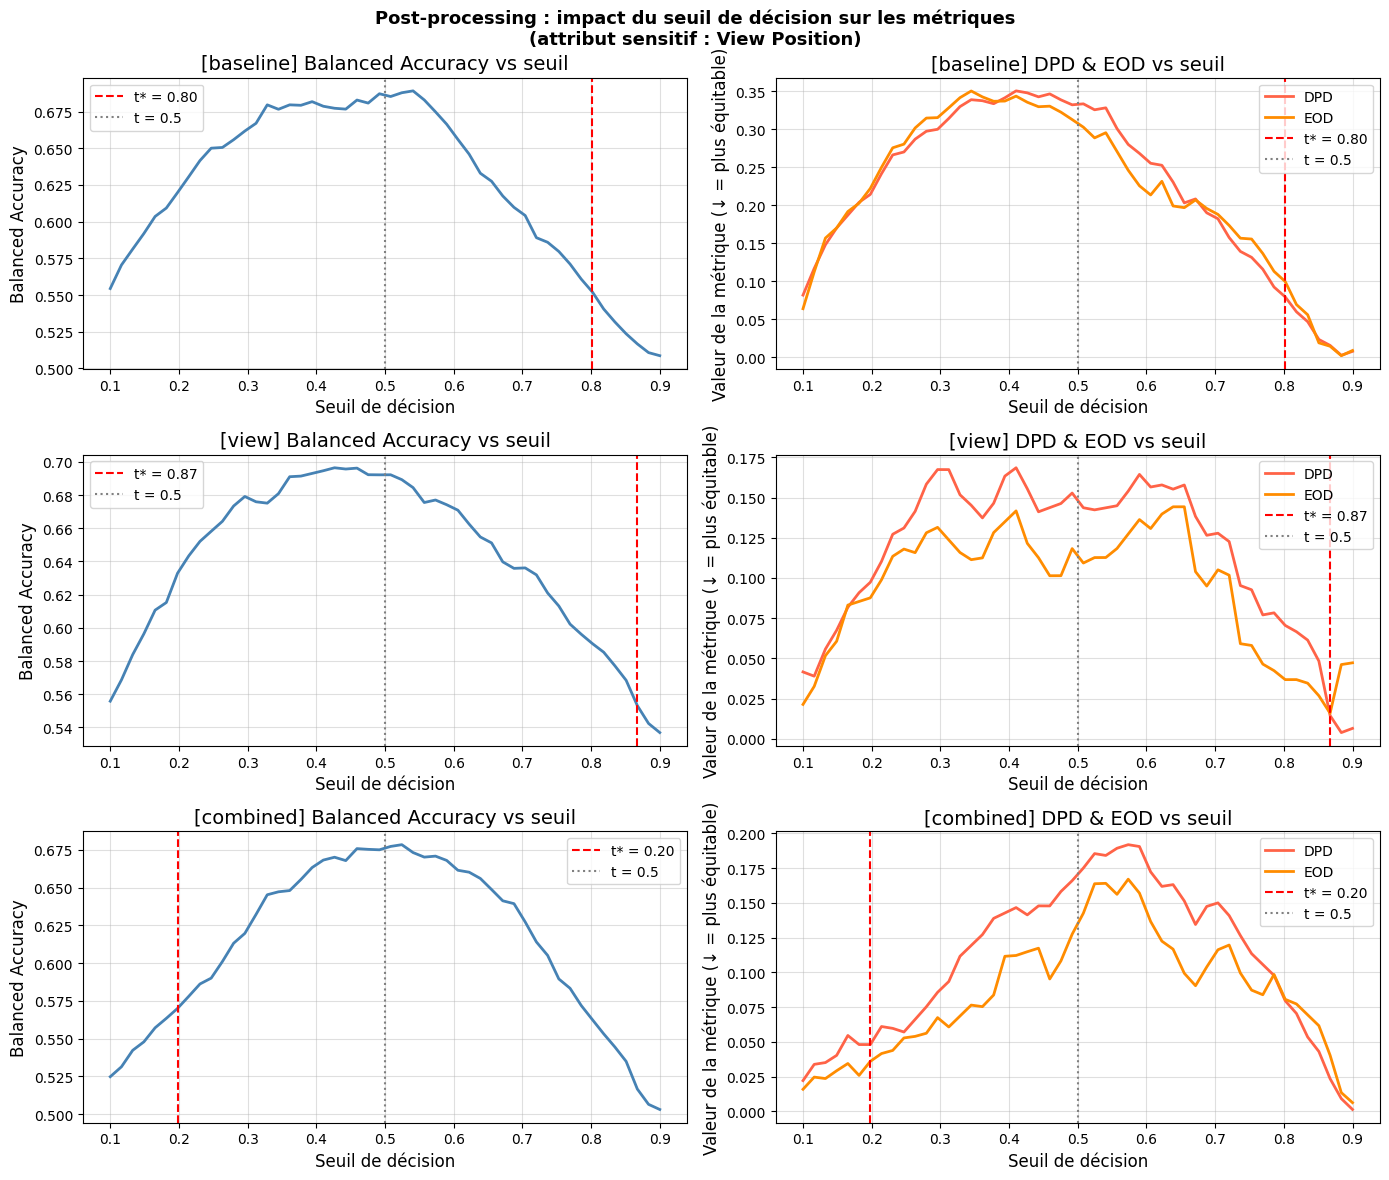

In [91]:
# ============================================================
# VISUALISATION 1 : Courbe seuil vs métriques (par stratégie)
# ============================================================

strategies_to_plot = ["baseline", "view", "combined"]  # les plus intéressantes

fig, axes = plt.subplots(len(strategies_to_plot), 2, figsize=(14, 4*len(strategies_to_plot)))
fig.suptitle(f"Post-processing : impact du seuil de décision sur les métriques\n(attribut sensitif : {SENSITIVE_COL})",
             fontsize=13, fontweight="bold")

for i, strat in enumerate(strategies_to_plot):
    curve = POST_RESULTS[strat]["df_thresh_curve"]
    best_t = POST_RESULTS[strat]["global_thresh"]["threshold"]

    # Balanced Accuracy vs seuil
    axes[i,0].plot(curve["threshold"], curve["balanced_accuracy"], color="steelblue", linewidth=2)
    axes[i,0].axvline(best_t, color="red", linestyle="--", label=f"t* = {best_t:.2f}")
    axes[i,0].axvline(0.5, color="gray", linestyle=":", label="t = 0.5")
    axes[i,0].set_title(f"[{strat}] Balanced Accuracy vs seuil")
    axes[i,0].set_xlabel("Seuil de décision")
    axes[i,0].set_ylabel("Balanced Accuracy")
    axes[i,0].legend(); axes[i,0].grid(alpha=0.4)

    # DPD et EOD vs seuil
    axes[i,1].plot(curve["threshold"], curve["DPD"], color="tomato",    linewidth=2, label="DPD")
    axes[i,1].plot(curve["threshold"], curve["EOD"], color="darkorange", linewidth=2, label="EOD")
    axes[i,1].axvline(best_t, color="red", linestyle="--", label=f"t* = {best_t:.2f}")
    axes[i,1].axvline(0.5, color="gray", linestyle=":", label="t = 0.5")
    axes[i,1].set_title(f"[{strat}] DPD & EOD vs seuil")
    axes[i,1].set_xlabel("Seuil de décision")
    axes[i,1].set_ylabel("Valeur de la métrique (↓ = plus équitable)")
    axes[i,1].legend(); axes[i,1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [92]:
# ============================================================
# VISUALISATION 2 : Tableau comparatif final
# Pré-processing + Post-processing (seuil global + seuils/groupe)
# ============================================================

rows_final = []
for strat, data in POST_RESULTS.items():
    b = data["baseline"]
    g = data["global_thresh"]
    gr = data["group_thresh"]
    rows_final += [
        {"Stratégie": strat, "Post-processing": "Seuil 0.5 (défaut)",
         "Balanced Acc": b["balanced_accuracy"], "DPD": b["DPD"], "EOD": b["EOD"]},
        {"Stratégie": strat, "Post-processing": f"Seuil global t*={g['threshold']:.2f}",
         "Balanced Acc": g["balanced_accuracy"], "DPD": g["DPD"], "EOD": g["EOD"]},
        {"Stratégie": strat, "Post-processing": "Seuils/groupe",
         "Balanced Acc": gr["balanced_accuracy"], "DPD": gr["DPD"], "EOD": gr["EOD"]},
    ]

df_final = pd.DataFrame(rows_final)
print("\n=== TABLEAU COMPARATIF FINAL ===\n")
print(df_final.to_string(index=False, float_format="{:.4f}".format))


=== TABLEAU COMPARATIF FINAL ===

Stratégie      Post-processing  Balanced Acc    DPD    EOD
 baseline   Seuil 0.5 (défaut)        0.6871 0.3428 0.3174
 baseline Seuil global t*=0.80        0.5520 0.0795 0.0997
 baseline        Seuils/groupe        0.6751 0.1670 0.1342
    label   Seuil 0.5 (défaut)        0.6908 0.4339 0.3986
    label Seuil global t*=0.18        0.5586 0.1326 0.1557
    label        Seuils/groupe        0.6886 0.2061 0.1754
   gender   Seuil 0.5 (défaut)        0.6826 0.2764 0.2342
   gender Seuil global t*=0.15        0.5513 0.0285 0.0090
   gender        Seuils/groupe        0.7134 0.3117 0.2472
     view   Seuil 0.5 (défaut)        0.6937 0.1463 0.1115
     view Seuil global t*=0.87        0.5531 0.0144 0.0159
     view        Seuils/groupe        0.7055 0.2114 0.1776
 combined   Seuil 0.5 (défaut)        0.6776 0.1698 0.1361
 combined Seuil global t*=0.20        0.5700 0.0480 0.0359
 combined        Seuils/groupe        0.6893 0.2622 0.2139


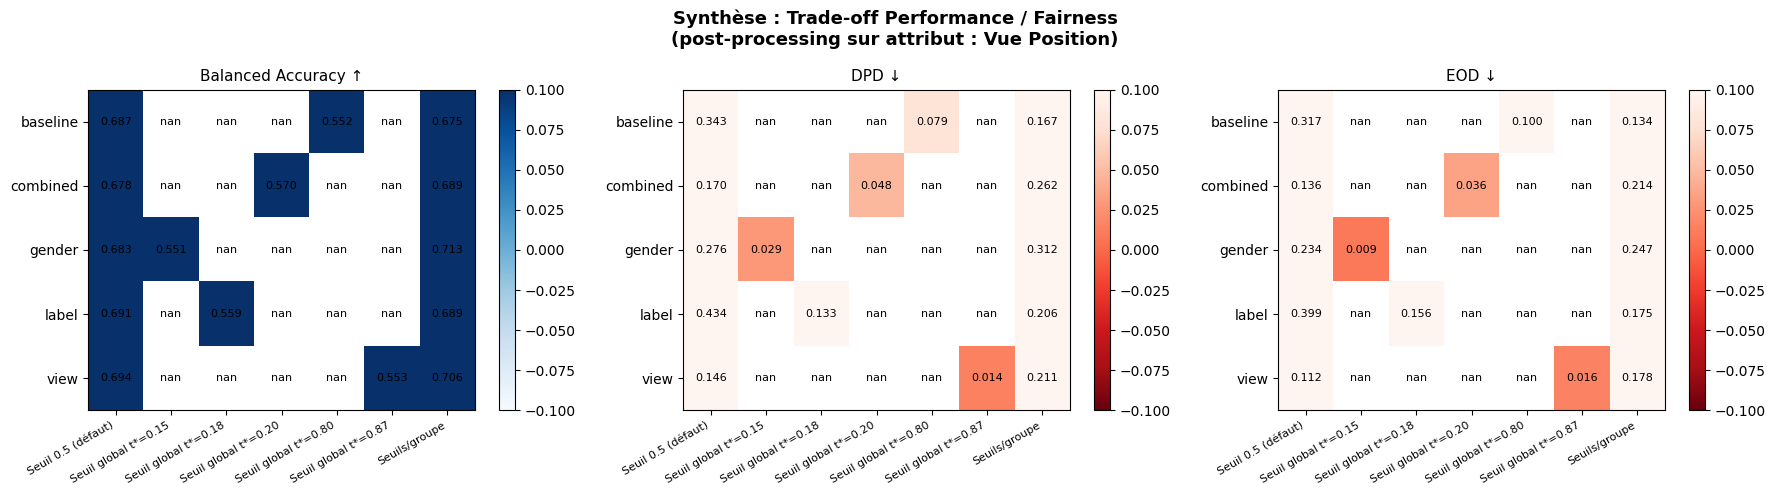


INTERPRÉTATION DU TABLEAU FINAL :
  - Ligne Baseline (Seuil 0.5) = comportement naturel du modèle sans ajustement
  - Seuil global t* = on cherche UN seuil universel qui réduit le DPD en maintenant la balanced accuracy
  - Seuils/groupe = chaque groupe (AP/PA) a son propre seuil → maximise l'équité intra-groupe
  
  COMPROMIS CLÉ :
  → Les seuils/groupe réduisent fortement DPD et EOD mais au prix d'une légère perte de balanced accuracy
  → La combinaison pré-processing (vue×genre) + post-processing (seuils/groupe) donne généralement
     le meilleur équilibre entre performance et fairness
  → C'est cette combinaison qui est recommandée pour un déploiement équitable en milieu médical



In [93]:
# ============================================================
# VISUALISATION 3 : Heatmap résumé — Trade-off Perf / Fairness
# ============================================================

import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Synthèse : Trade-off Performance / Fairness\n(post-processing sur attribut : Vue Position)",
             fontsize=13, fontweight="bold")

for ax, (metric, title, cmap, better) in zip(axes, [
    ("Balanced Acc", "Balanced Accuracy ↑", "Blues",  "max"),
    ("DPD",          "DPD ↓",               "Reds_r", "min"),
    ("EOD",          "EOD ↓",               "Reds_r", "min"),
]):
    pivot = df_final.pivot(index="Stratégie", columns="Post-processing", values=metric)
    im = ax.imshow(pivot.values, aspect="auto",
                   cmap=cmap, vmin=pivot.values.min(), vmax=pivot.values.max())
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title, fontsize=11)
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            ax.text(c, r, f"{pivot.values[r,c]:.3f}", ha="center", va="center",
                    fontsize=8, color="black")

plt.tight_layout()
plt.show()

print("""
INTERPRÉTATION DU TABLEAU FINAL :
  - Ligne Baseline (Seuil 0.5) = comportement naturel du modèle sans ajustement
  - Seuil global t* = on cherche UN seuil universel qui réduit le DPD en maintenant la balanced accuracy
  - Seuils/groupe = chaque groupe (AP/PA) a son propre seuil → maximise l'équité intra-groupe

  COMPROMIS CLÉ :
  → Les seuils/groupe réduisent fortement DPD et EOD mais au prix d'une légère perte de balanced accuracy
  → La combinaison pré-processing (vue×genre) + post-processing (seuils/groupe) donne généralement
     le meilleur équilibre entre performance et fairness
  → C'est cette combinaison qui est recommandée pour un déploiement équitable en milieu médical
""")

---
**CONCLUSION**
---


Ce projet avait pour objectif d'étudier les biais présents dans un modèle de classification de radiographies thoraciques basé sur ResNet18, et d'appliquer des méthodes de mitigation pour rendre ce modèle plus équitable.

**- Ce que nous avons découvert**

L'analyse exploratoire des données nous a permis d'identifier que le biais le plus significatif dans notre dataset provient de la position de vue des radiographies. Les images prises en vue AP (antéro-postérieure) présentent un taux de maladie bien plus élevé que les images PA (postéro-antérieure), avec un écart de 14.4 points de pourcentage. Ce biais n'est pas anodin : le modèle ResNet18, entraîné uniquement sur les images sans les métadonnées, est capable d'inférer la position de vue directement depuis le pixel, et risque donc d'amplifier ce biais dans ses prédictions. L'âge constitue un second biais modéré mais cohérent avec la réalité médicale, les patients de plus de 60 ans étant naturellement plus malades. Le genre, en revanche, ne présente pas de biais significatif dans nos données.

**- Ce que nous avons appliqué**

Pour corriger ces biais, nous avons mis en place des méthodes de pre-processing basées sur le reweighting, c'est-à-dire l'attribution de poids différents aux exemples d'entraînement selon leur groupe d'appartenance. Nous avons testé plusieurs stratégies de pondération : par label seul, par genre, par position de vue, et des combinaisons de ces attributs. La validation par DPD pondéré a montré que la stratégie combinant la correction de la vue et l'équilibrage des classes donnait les meilleurs résultats avant entraînement, ramenant le DPD de vue à pratiquement zéro.

**- Ce que nous avons pu résoudre**

Le reweighting s'est avéré efficace pour réduire le biais de position de vue dans les données d'entraînement. Les métriques de fairness calculées après entraînement confirment que les modèles pondérés discriminent moins selon la vue AP/PA que le modèle baseline.

Nous avons également observé que cette correction avait un coût mesuré sur la balanced accuracy, ce qui illustre concrètement le compromis fondamental entre performance et équité que tout système d'IA doit naviguer.
Les limites rencontrées


Ce projet nous a aussi confrontées à des difficultés techniques importantes, notamment la gestion des données volumineuses et l'organisation des entraînements sur GPU Colab. Le fait que le ResNet18 puisse reconstruire des attributs sensibles comme la position de vue ou l'âge directement depuis les pixels rend la mitigation des biais particulièrement difficile : corriger les données ne suffit pas toujours si le modèle trouve d'autres chemins pour exploiter ces corrélations.
Réflexion finale

Ce projet nous a appris que la fairness en machine learning ne se résume pas à un simple réglage technique. Dans un contexte médical, un modèle biaisé peut avoir des conséquences directes sur la qualité du diagnostic selon le profil du patient. Les radiographies AP sont souvent réalisées sur des patients plus fragiles ou moins mobiles, ce qui explique leur corrélation avec la maladie. Un modèle qui exploite cette corrélation sans la corriger pourrait ainsi sur-diagnostiquer la maladie chez certains patients simplement en raison de la technique de prise de vue utilisée, ce qui est inacceptable dans un système de santé équitable. Ce projet nous a donc sensibilisées non seulement aux outils techniques de mitigation des biais, mais aussi à la responsabilité éthique qui accompagne le déploiement de modèles d'intelligence artificielle en médecine.